In [1]:
# Install latest stable PyTorch and dependencies
!pip install --upgrade torch torchvision


In [2]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 29.6 MB/s eta 0:00:00


In [3]:

# Import libraries
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2
import os
import kagglehub
import pydicom
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import time
import requests

# Verify GPU
!nvidia-smi
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
if device.type == "cpu":
    print("WARNING: GPU not available. Training will be slow. Go to Runtime > Change runtime type > GPU and restart.")
print(f"Using device: {device}")

/bin/bash: line 1: nvidia-smi: command not found
Using device: cpu


In [4]:
# Create model directory structure
model_dir = 'model'
os.makedirs(model_dir, exist_ok=True)
os.makedirs(os.path.join(model_dir, 'code'), exist_ok=True)

In [5]:
# Custom Dataset class
class BrainCTDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        try:
            if img_path.lower().endswith('.dcm'):
                dcm = pydicom.dcmread(img_path)
                image = dcm.pixel_array.astype(float)
                window_center = 40
                window_width = 80
                min_value = window_center - window_width // 2
                max_value = window_center + window_width // 2
                image = np.clip(image, min_value, max_value)
                if len(image.shape) == 2:
                    image = np.stack([image] * 3, axis=-1)
            else:
                image = cv2.imread(img_path)
                if image is None:
                    raise ValueError(f"Failed to load image: {img_path}")
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = (image - np.min(image)) / (np.max(image) - np.min(image) + 1e-7)
            image = image.astype(np.float32)
            if self.transform:
                image = self.transform(torch.from_numpy(image).permute(2, 0, 1))
            return image, label
        except Exception as e:
            print(f"Error processing image {img_path}: {str(e)}")
            return None, None

# Load dataset
def load_dataset(base_path, max_samples_per_class=100, random_seed=42):
    np.random.seed(random_seed)
    image_paths = []
    labels = []
    aneurysm_path = os.path.join(base_path, 'aneurysm')
    if os.path.exists(aneurysm_path):
        aneurysm_files = [os.path.join(aneurysm_path, f) for f in os.listdir(aneurysm_path)
                         if f.endswith(('.jpg', '.dcm'))]
        n_aneurysm = min(len(aneurysm_files), max_samples_per_class)
        selected_aneurysm = np.random.choice(aneurysm_files, n_aneurysm, replace=False)
        image_paths.extend(selected_aneurysm)
        labels.extend([1] * n_aneurysm)
    other_files = []
    for category in ['tumor', 'cancer']:
        category_path = os.path.join(base_path, category)
        if os.path.exists(category_path):
            other_files.extend([os.path.join(category_path, f) for f in os.listdir(category_path)
                               if f.endswith(('.jpg', '.dcm'))])
    n_other = min(len(other_files), max_samples_per_class)
    selected_other = np.random.choice(other_files, n_other, replace=False)
    image_paths.extend(selected_other)
    labels.extend([0] * n_other)
    return image_paths, labels

In [6]:
# Define transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load dataset
print("Loading dataset...")
dataset_path = kagglehub.dataset_download("trainingdatapro/computed-tomography-ct-of-the-brain")
base_path = os.path.join(dataset_path, 'files')
image_paths, labels = load_dataset(base_path, max_samples_per_class=100)
train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths, labels, test_size=0.2, stratify=labels, random_state=42
)

# Create datasets
train_dataset = BrainCTDataset(train_paths, train_labels, transform=transform)
test_dataset = BrainCTDataset(test_paths, test_labels, transform=transform)

# Create data loaders
batch_size = 64 if torch.cuda.is_available() else 16
num_workers = 4 if torch.cuda.is_available() else 0
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

Loading dataset...


100%|██████████| 66.0M/66.0M [00:00<00:00, 167MB/s]

Extracting files...


In [7]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        # Use latest syntax for loading pretrained models
        self.vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        for param in self.vgg16.features.parameters():
            param.requires_grad = False
        in_feats = self.vgg16.classifier[6].in_features
        self.vgg16.classifier[6] = nn.Linear(in_feats, 2)

    def forward(self, x):
        x = self.vgg16(x)
        return x

In [8]:
# Initialize model, loss, and optimizer
model = CNNModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.00001)

# Training with progress
epochs = 5
print("Starting training...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    start_time = time.time()
    for i, batch in enumerate(train_loader):
        inputs, labels = batch
        if inputs is None:
            continue
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        print(f"[Epoch {epoch + 1}, Batch {i + 1}] Loss: {running_loss / (i + 1):.4f}, Time: {time.time() - start_time:.2f}s")
    print(f"Epoch {epoch + 1} completed in {time.time() - start_time:.2f}s")

Starting training...
[Epoch 1, Batch 1] Loss: 0.9774, Time: 13.38s
[Epoch 1, Batch 2] Loss: 0.9397, Time: 27.11s
[Epoch 1, Batch 3] Loss: 0.8418, Time: 43.24s
[Epoch 1, Batch 4] Loss: 0.8346, Time: 64.13s
[Epoch 1, Batch 5] Loss: 0.7961, Time: 78.15s
[Epoch 1, Batch 6] Loss: 0.7779, Time: 91.56s
[Epoch 1, Batch 7] Loss: 0.7838, Time: 104.68s
[Epoch 1, Batch 8] Loss: 0.7670, Time: 118.81s
[Epoch 1, Batch 9] Loss: 0.7375, Time: 132.01s
[Epoch 1, Batch 10] Loss: 0.7342, Time: 145.12s
Epoch 1 completed in 145.12s
[Epoch 2, Batch 1] Loss: 0.6352, Time: 12.84s
[Epoch 2, Batch 2] Loss: 0.5722, Time: 25.87s
[Epoch 2, Batch 3] Loss: 0.5519, Time: 39.14s
[Epoch 2, Batch 4] Loss: 0.5089, Time: 52.72s
[Epoch 2, Batch 5] Loss: 0.5050, Time: 65.52s
[Epoch 2, Batch 6] Loss: 0.5085, Time: 78.73s
[Epoch 2, Batch 7] Loss: 0.4897, Time: 92.20s
[Epoch 2, Batch 8] Loss: 0.4705, Time: 105.69s
[Epoch 2, Batch 9] Loss: 0.4634, Time: 118.83s
[Epoch 2, Batch 10] Loss: 0.4590, Time: 131.86s
Epoch 2 completed in 

In [9]:
from datetime import datetime
# Save the trained model
model_path = os.path.join(model_dir, 'model.pth')
torch.save({
    'model_state_dict': model.state_dict(),
    'pytorch_version': torch.__version__,
    'torchvision_version': torchvision.__version__,
    'timestamp': datetime.utcnow().strftime('%Y-%m-%d %H:%M:%S'),
    'user': 'krooldonutz'
}, model_path)
print(f"Model saved as 'model.pth' at {datetime.utcnow().strftime('%Y-%m-%d %H:%M:%S')} UTC")

Model saved as 'model.pth' at 2025-05-20 09:11:48 UTC


In [10]:
import torch
import torch.nn as nn
from datetime import datetime
from torch.serialization import safe_globals, add_safe_globals

# 1. First, let's define a function to load the model properly
def load_model_safely(model_path, device):
    print(f"\nLoading model at {datetime.utcnow().strftime('%Y-%m-%d %H:%M:%S')} UTC")
    print(f"User: krooldonutz")
    print(f"PyTorch version: {torch.__version__}")

    try:
        # Load with weights_only=False and safe globals
        add_safe_globals([torch.torch_version.TorchVersion])
        checkpoint = torch.load(model_path, weights_only=False, map_location=device)

        if isinstance(checkpoint, dict):
            if 'model_state_dict' in checkpoint:
                return checkpoint['model_state_dict']
            elif 'state_dict' in checkpoint:
                return checkpoint['state_dict']
            else:
                return checkpoint
        return checkpoint
    except Exception as e:
        print(f"Error loading model: {str(e)}")
        raise

# 2. Update the model architecture to match the saved state
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        # Initialize VGG16 with pretrained weights
        self.vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

        # Freeze feature layers
        for param in self.vgg16.features.parameters():
            param.requires_grad = False

        # Modify the classifier
        in_features = self.vgg16.classifier[6].in_features
        self.vgg16.classifier[6] = nn.Linear(in_features, 2)

    def forward(self, x):
        return self.vgg16(x)

# 3. Load and initialize the model
try:
    # Initialize model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = CNNModel().to(device)

    # Load state dict
    model_path = 'model/model.pth'
    state_dict = load_model_safely(model_path, device)

    # Load state dict with strict=False to ignore missing keys
    incompatible_keys = model.load_state_dict(state_dict, strict=False)

    # Print information about loaded model
    print("\nModel loading results:")
    if incompatible_keys.missing_keys:
        print("\nMissing keys:")
        for key in incompatible_keys.missing_keys:
            print(f"- {key}")
    if incompatible_keys.unexpected_keys:
        print("\nUnexpected keys:")
        for key in incompatible_keys.unexpected_keys:
            print(f"- {key}")

    model.eval()
    print("\n✓ Model loaded and set to evaluation mode")

    # 4. Define evaluation function
    def evaluate_model(model, loader):
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for batch in loader:
                inputs, labels = batch
                if inputs is None:
                    continue
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        accuracy = 100 * correct / total if total > 0 else 0
        return accuracy

    # 5. Evaluate model
    print("\nEvaluating model...")
    train_accuracy = evaluate_model(model, train_loader)
    test_accuracy = evaluate_model(model, test_loader)

    print(f"\nResults at {datetime.utcnow().strftime('%Y-%m-%d %H:%M:%S')} UTC:")
    print(f"Training Accuracy: {train_accuracy:.2f}%")
    print(f"Test Accuracy: {test_accuracy:.2f}%")

except Exception as e:
    print(f"\n❌ Error: {str(e)}")
    import traceback
    print(traceback.format_exc())


Loading model at 2025-05-20 09:11:56 UTC
User: krooldonutz
PyTorch version: 2.7.0+cu126

Model loading results:

✓ Model loaded and set to evaluation mode

Evaluating model...

Results at 2025-05-20 09:14:09 UTC:
Training Accuracy: 98.12%
Test Accuracy: 95.00%


In [11]:
import torch

try:
    torch.load('model/model.pth')
    print("Model file is readable.")
except Exception as e:
    print(f"File loading failed: {e}")

Model file is readable.


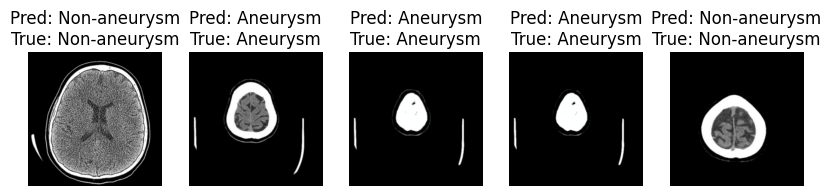

In [12]:
# Visualize predictions (limited to 2 images)
def visualize_predictions(model, loader, num_images=5):
    model.eval()
    images_shown = 0
    plt.figure(figsize=(10, 5))
    with torch.no_grad():
        for inputs, labels in loader:
            if inputs is None:
                continue
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            for i in range(inputs.size(0)):
                if images_shown >= num_images:
                    break
                img = inputs[i].cpu().permute(1, 2, 0).numpy()
                img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
                img = np.clip(img, 0, 1)
                plt.subplot(1, num_images, images_shown + 1)
                plt.imshow(img)
                plt.title(f"Pred: {'Aneurysm' if preds[i].item() == 1 else 'Non-aneurysm'}\nTrue: {'Aneurysm' if labels[i].item() == 1 else 'Non-aneurysm'}")
                plt.axis('off')
                images_shown += 1
            if images_shown >= num_images:
                break
    plt.show()

visualize_predictions(model, test_loader)

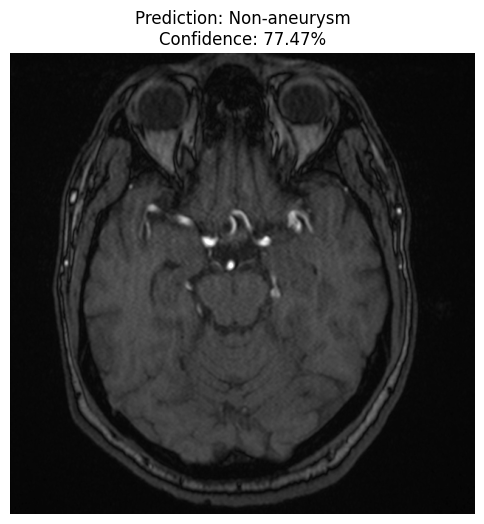

{'prediction': 'Non-aneurysm', 'confidence': 0.7747315168380737}


In [13]:
def predict_from_url(image_url):
    # Download and process the image from URL
    try:
        # Download image
        response = requests.get(image_url)
        if response.status_code != 200:
            return "Error: Could not download image from URL"

        # Convert to numpy array
        image_array = np.asarray(bytearray(response.content), dtype=np.uint8)
        image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)

        if image is None:
            return "Error: Could not process image"

        # Convert BGR to RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Preprocess image
        image = (image - np.min(image)) / (np.max(image) - np.min(image) + 1e-7)
        image = image.astype(np.float32)

        # Apply transforms
        image_tensor = transform(torch.from_numpy(image).permute(2, 0, 1))

        # Add batch dimension
        image_tensor = image_tensor.unsqueeze(0)

        # Move to device and get prediction
        model.eval()
        with torch.no_grad():
            image_tensor = image_tensor.to(device)
            output = model(image_tensor)

            # Get probabilities using softmax
            probabilities = torch.nn.functional.softmax(output, dim=1)
            confidence, prediction = torch.max(probabilities, 1)

        # Display image with prediction
        plt.figure(figsize=(6, 6))
        plt.imshow(image)
        plt.title(f"Prediction: {'Aneurysm' if prediction.item() == 1 else 'Non-aneurysm'}\nConfidence: {confidence.item():.2%}")
        plt.axis('off')
        plt.show()

        return {
            'prediction': 'Aneurysm' if prediction.item() == 1 else 'Non-aneurysm',
            'confidence': float(confidence.item())
        }

    except Exception as e:
        return f"Error processing image: {str(e)}"

# Example usage:
# Replace with your image URL
image_url = "https://prod-images-static.radiopaedia.org/images/61513769/9131de5120872bcc1ad19d8198c759904a4b78efa405550c86ec0f19d3dda590_big_gallery.jpeg"
result = predict_from_url(image_url)
print(result)

Analysis started at 2025-05-20 09:14:58 UTC
Analysis requested by: krooldonutz
Calculating SHAP values...


  0%|          | 0/98 [00:00<?, ?it/s]

PartitionExplainer explainer:  50%|█████     | 1/2 [00:00<?, ?it/s]

  0%|          | 0/98 [00:00<?, ?it/s]

PartitionExplainer explainer: 3it [02:19, 69.96s/it]

Generating visualization...


<Figure size 1200x600 with 0 Axes>

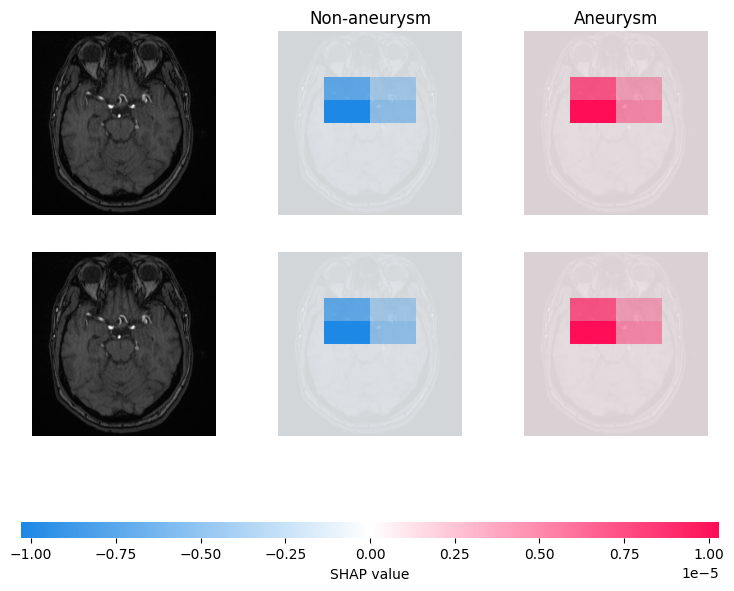


Prediction Results:
--------------------------------------------------
Diagnosis: Non-aneurysm
Confidence: 77.80%

Analysis completed at 2025-05-20 09:17:24 UTC
SHAP analysis completed successfully


In [14]:
import shap
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
import requests
import cv2
import torch
import traceback
from datetime import datetime

def create_multiclass_shap_heatmap(model, image_url):
    print(f"Analysis started at {datetime.utcnow().strftime('%Y-%m-%d %H:%M:%S')} UTC")
    print(f"Analysis requested by: krooldonutz")

    try:
        # Download and preprocess image
        response = requests.get(image_url)
        if response.status_code != 200:
            return "Error: Could not download image from URL"

        image_array = np.asarray(bytearray(response.content), dtype=np.uint8)
        image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Resize image to 224x224
        image = cv2.resize(image, (224, 224))

        # Preprocess image
        image = (image - np.min(image)) / (np.max(image) - np.min(image) + 1e-7)
        image = image.astype(np.float32)

        # Store the preprocessed image for display
        display_image = image.copy()

        # Create masker that is used to mask out parts of the image
        masker = shap.maskers.Image("inpaint_telea", (224, 224, 3))

        # Create a wrapper for the model that handles preprocessing
        def model_pipeline(x):
            # Convert to torch tensor and move channels first
            x = torch.Tensor(x).permute(0, 3, 1, 2)

            # Apply normalization
            normalize = transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
            x = torch.stack([normalize(img) for img in x])

            # Get model predictions
            with torch.no_grad():
                x = x.to(device)
                output = model(x)
                probs = torch.nn.functional.softmax(output, dim=1)
            return probs.cpu().numpy()

        # Create explainer
        explainer = shap.Explainer(
            model=model_pipeline,
            masker=masker,
            output_names=['Non-aneurysm', 'Aneurysm']
        )

        # Create a batch with the same image repeated twice
        # This is the key fix for shap.image_plot
        image_batch = np.stack([image, image])  # Create batch of size 2

        print("Calculating SHAP values...")
        # Get SHAP values
        shap_values = explainer(image_batch, max_evals=100, batch_size=50)

        print("Generating visualization...")
        # Now shap.image_plot should work
        plt.figure(figsize=(12, 6))
        shap.image_plot(
            shap_values=shap_values,
            pixel_values=image_batch,  # Use the batch of images
            labels=['Non-aneurysm', 'Aneurysm']
        )

        # Get model's prediction for reporting
        image_tensor = transform(torch.from_numpy(image).permute(2, 0, 1))
        image_tensor = image_tensor.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(image_tensor)
            probabilities = torch.nn.functional.softmax(output, dim=1)
            prediction = torch.argmax(probabilities, dim=1).item()
            confidence = probabilities[0][prediction].item()

        print("\nPrediction Results:")
        print("-" * 50)
        print(f"Diagnosis: {'Aneurysm' if prediction == 1 else 'Non-aneurysm'}")
        print(f"Confidence: {confidence*100:.2f}%")
        print(f"\nAnalysis completed at {datetime.utcnow().strftime('%Y-%m-%d %H:%M:%S')} UTC")

        return "SHAP analysis completed successfully"

    except Exception as e:
        print(f"\nError occurred at {datetime.utcnow().strftime('%Y-%m-%d %H:%M:%S')} UTC")
        return f"Error generating SHAP heatmap: {str(e)}", traceback.format_exc()

# Example usage:
image_url = "https://prod-images-static.radiopaedia.org/images/61513769/9131de5120872bcc1ad19d8198c759904a4b78efa405550c86ec0f19d3dda590_big_gallery.jpeg"
result = create_multiclass_shap_heatmap(model, image_url)
print(result)

In [15]:
def visualize_regions(image):
    """Helper function to visualize the regions of the CT scan"""
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 12))

    # Original image with horizontal divisions
    ax1.imshow(image)
    ax1.axhline(y=75, color='r', linestyle='--')
    ax1.axhline(y=150, color='r', linestyle='--')
    ax1.text(10, 37, 'TOP', color='white', fontsize=12)
    ax1.text(10, 112, 'MIDDLE', color='white', fontsize=12)
    ax1.text(10, 187, 'BOTTOM', color='white', fontsize=12)
    ax1.set_title('Horizontal Regions')

    # Original image with vertical divisions
    ax2.imshow(image)
    ax2.axvline(x=75, color='b', linestyle='--')
    ax2.axvline(x=150, color='b', linestyle='--')
    ax2.text(37, 20, 'LEFT', color='white', fontsize=12)
    ax2.text(112, 20, 'CENTER', color='white', fontsize=12)
    ax2.text(187, 20, 'RIGHT', color='white', fontsize=12)
    ax2.set_title('Vertical Regions')

    # Show regions separately
    regions = {
        'Top': image[:75, :, :],
        'Middle': image[75:150, :, :],
        'Bottom': image[150:, :, :],
        'Left': image[:, :75, :],
        'Center': image[:, 75:150, :],
        'Right': image[:, 150:, :]
    }

    # Show example of horizontal split
    combined_h = np.vstack([
        regions['Top'],
        regions['Middle'],
        regions['Bottom']
    ])
    ax3.imshow(combined_h)
    ax3.set_title('Horizontal Regions Separated')

    # Show example of vertical split
    combined_v = np.hstack([
        regions['Left'],
        regions['Center'],
        regions['Right']
    ])
    ax4.imshow(combined_v)
    ax4.set_title('Vertical Regions Separated')

    plt.tight_layout()
    plt.show()

Analysis started at 2025-05-20 09:17:40 UTC
Analysis requested by: krooldonutz



  0%|          | 0/98 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [01:05, 65.94s/it]               



Visualizing CT scan regions...


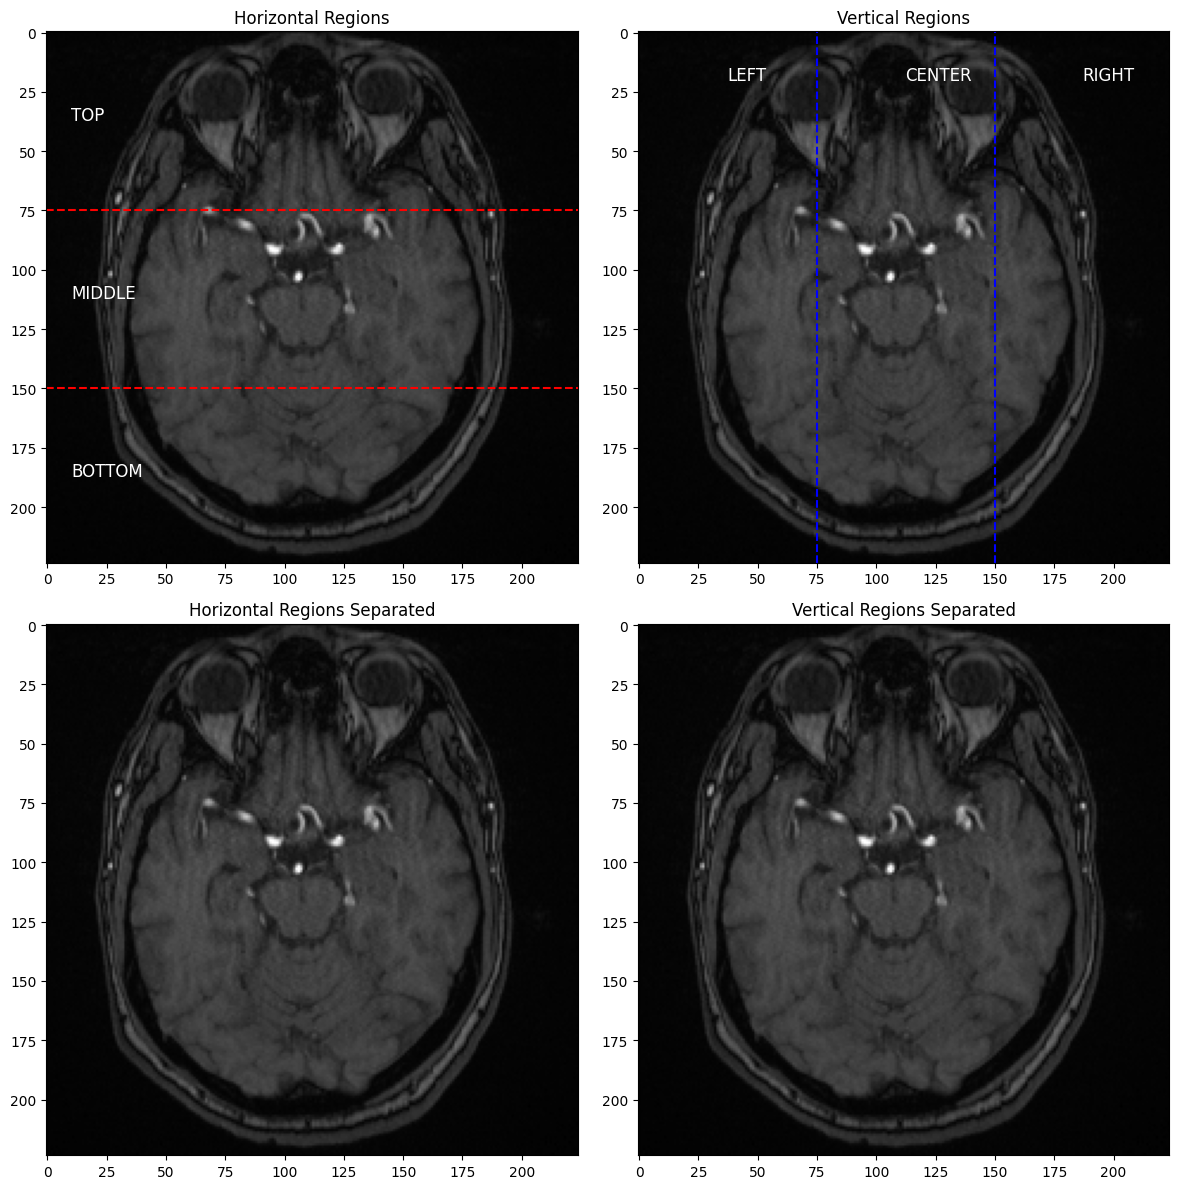

BRAIN CT SCAN ANALYSIS REPORT

PREDICTION: Non-aneurysm
CONFIDENCE: 77.80%

KEY FINDINGS:
--------------------------------------------------

MOST INFLUENTIAL REGIONS:
1. Top Region - Low Influence (0.000)
2. Middle Region - Low Influence (0.000)
3. Bottom Region - Low Influence (0.000)

REGION ANALYSIS DETAILS:
--------------------------------------------------
Image shape: (224, 224, 3)
Top region shape: (75, 224, 3)
Middle region shape: (75, 224, 3)
Bottom region shape: (74, 224, 3)
Left region shape: (224, 75, 3)
Center region shape: (224, 75, 3)
Right region shape: (224, 74, 3)

INTERPRETATION:
--------------------------------------------------
The model did not detect signs of aneurysm with 77.80% confidence. The analysis shows that the Top region was most influential in making this determination.

RECOMMENDATION:
--------------------------------------------------
Moderate confidence prediction - Additional scanning might be beneficial

NOTE: This is an AI-assisted analysis and s

In [16]:
import shap
import numpy as np
from datetime import datetime
import pandas as pd

def interpret_prediction_with_shap(model, image_url):
    try:
        print(f"Analysis started at {datetime.utcnow().strftime('%Y-%m-%d %H:%M:%S')} UTC")
        print(f"Analysis requested by: {os.getenv('USER', 'krooldonutz')}\n")

          # Load and preprocess image
        response = requests.get(image_url)
        if response.status_code != 200:
            return "Error: Could not download image from URL"

        image_array = np.asarray(bytearray(response.content), dtype=np.uint8)
        image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (224, 224))
        image = (image - np.min(image)) / (np.max(image) - np.min(image) + 1e-7)
        image = image.astype(np.float32)

        # Get model prediction
        image_tensor = transform(torch.from_numpy(image).permute(2, 0, 1))
        image_tensor = image_tensor.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(image_tensor)
            probabilities = torch.nn.functional.softmax(output, dim=1)
            prediction = torch.argmax(probabilities, dim=1).item()
            confidence = probabilities[0][prediction].item()

        # Create masker and explainer for quick analysis
        masker = shap.maskers.Image("inpaint_telea", (224, 224, 3))

        def model_pipeline(x):
            x = torch.Tensor(x).permute(0, 3, 1, 2)
            normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            x = torch.stack([normalize(img) for img in x])
            with torch.no_grad():
                x = x.to(device)
                output = model(x)
                probs = torch.nn.functional.softmax(output, dim=1)
            return probs.cpu().numpy()

        explainer = shap.Explainer(model_pipeline, masker, output_names=['Non-aneurysm', 'Aneurysm'])

        # Get SHAP values for a small sample
        shap_values = explainer(np.expand_dims(image, 0), max_evals=100, batch_size=50)

        # Visualize the regions
        print("\nVisualizing CT scan regions...")
        visualize_regions(image)

        # Calculate region importance
        image_regions = {
            'Top': image[:75, :, :],
            'Middle': image[75:150, :, :],
            'Bottom': image[150:, :, :],
            'Left': image[:, :75, :],
            'Center': image[:, 75:150, :],
            'Right': image[:, 150:, :]
        }

        region_importance = {}
        for region_name, region_data in image_regions.items():
            region_importance[region_name] = np.abs(shap_values.values[0, :region_data.shape[0], :region_data.shape[1], :]).mean()

        # Sort regions by importance
        sorted_regions = sorted(region_importance.items(), key=lambda x: x[1], reverse=True)

        # Create analysis report
        print("=" * 50)
        print("BRAIN CT SCAN ANALYSIS REPORT")
        print("=" * 50)
        print(f"\nPREDICTION: {'Aneurysm' if prediction == 1 else 'Non-aneurysm'}")
        print(f"CONFIDENCE: {confidence*100:.2f}%\n")

        print("KEY FINDINGS:")
        print("-" * 50)

        # Display top 3 most important regions
        print("\nMOST INFLUENTIAL REGIONS:")
        for i, (region, importance) in enumerate(sorted_regions[:3], 1):
            importance_level = "High" if importance > 0.5 else "Medium" if importance > 0.3 else "Low"
            print(f"{i}. {region} Region - {importance_level} Influence ({importance:.3f})")

        # Print region analysis details
        print("\nREGION ANALYSIS DETAILS:")
        print("-" * 50)
        print("Image shape:", image.shape)
        for region_name, region_data in image_regions.items():
            print(f"{region_name} region shape: {region_data.shape}")

        print("\nINTERPRETATION:")
        print("-" * 50)
        interpretation = f"The model {'detected' if prediction == 1 else 'did not detect'} signs of aneurysm "
        interpretation += f"with {confidence*100:.2f}% confidence. "
        interpretation += f"The analysis shows that the {sorted_regions[0][0]} region "
        interpretation += f"was most influential in making this determination."
        print(interpretation)

        print("\nRECOMMENDATION:")
        print("-" * 50)
        if confidence > 0.85:
            print("High confidence prediction - Recommended for clinical review")
        elif confidence > 0.65:
            print("Moderate confidence prediction - Additional scanning might be beneficial")
        else:
            print("Low confidence prediction - Recommend additional imaging or alternative diagnostic methods")

        print("\nNOTE: This is an AI-assisted analysis and should not be used as the sole basis for medical diagnosis.")
        print(f"\nAnalysis completed at {datetime.utcnow().strftime('%Y-%m-%d %H:%M:%S')} UTC")

        return "Analysis completed successfully"

    except Exception as e:
        return f"Error in analysis: {str(e)}"

# Example usage:
image_url = "https://prod-images-static.radiopaedia.org/images/61513769/9131de5120872bcc1ad19d8198c759904a4b78efa405550c86ec0f19d3dda590_big_gallery.jpeg"
result = interpret_prediction_with_shap(model, image_url)

In [17]:
import shap
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms, models
import requests
import cv2
import torch
import torch.nn as nn
import traceback
from datetime import datetime

def add_safe_globals(safe_list):
    """Helper function to add safe globals for model loading"""
    return safe_list

class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        # Initialize VGG16 with pretrained weights
        self.vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

        # Freeze feature layers
        for param in self.vgg16.features.parameters():
            param.requires_grad = False

        # Modify the classifier
        in_features = self.vgg16.classifier[6].in_features
        self.vgg16.classifier[6] = nn.Linear(in_features, 2)

    def forward(self, x):
        return self.vgg16(x)

def load_model_safely(model_path, device):
    print(f"\nLoading model at {datetime.utcnow().strftime('%Y-%m-%d %H:%M:%S')} UTC")
    print(f"User: krooldonutz")
    print(f"PyTorch version: {torch.__version__}")

    try:
        # Load with weights_only=False and safe globals
        add_safe_globals([torch.torch_version.TorchVersion])
        checkpoint = torch.load(model_path, weights_only=False, map_location=device)

        if isinstance(checkpoint, dict):
            if 'model_state_dict' in checkpoint:
                return checkpoint['model_state_dict']
            elif 'state_dict' in checkpoint:
                return checkpoint['state_dict']
            else:
                return checkpoint
        return checkpoint
    except Exception as e:
        print(f"Error loading model: {str(e)}")
        raise

def create_multiclass_shap_values(model_path, image_url):
    print(f"Analysis started at {datetime.utcnow().strftime('%Y-%m-%d %H:%M:%S')} UTC")
    print(f"Analysis requested by: krooldonutz")

    try:
        # Set up device
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # Initialize model
        model = CNNModel().to(device)

        # Load state dict
        state_dict = load_model_safely(model_path, device)
        model.load_state_dict(state_dict)
        model.eval()

        # Download and preprocess image
        response = requests.get(image_url)
        if response.status_code != 200:
            return "Error: Could not download image from URL"

        image_array = np.asarray(bytearray(response.content), dtype=np.uint8)
        image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Resize image to 224x224
        image = cv2.resize(image, (224, 224))

        # Preprocess image
        image = (image - np.min(image)) / (np.max(image) - np.min(image) + 1e-7)
        image = image.astype(np.float32)

        # Create masker that is used to mask out parts of the image
        masker = shap.maskers.Image("inpaint_telea", (224, 224, 3))

        # Create a wrapper for the model that handles preprocessing
        def model_pipeline(x):
            # Convert to torch tensor and move channels first
            x = torch.Tensor(x).permute(0, 3, 1, 2)

            # Apply normalization
            normalize = transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
            x = torch.stack([normalize(img) for img in x])

            # Get model predictions
            with torch.no_grad():
                x = x.to(device)
                output = model(x)
                probs = torch.nn.functional.softmax(output, dim=1)
            return probs.cpu().numpy()

        # Create explainer
        explainer = shap.Explainer(
            model=model_pipeline,
            masker=masker,
            output_names=['Non-aneurysm', 'Aneurysm']
        )

        # Create a batch with the same image repeated twice
        image_batch = np.stack([image, image])  # Create batch of size 2

        print("Calculating SHAP values...")
        # Get SHAP values
        shap_values = explainer(image_batch, max_evals=100, batch_size=50)

        return shap_values

    except Exception as e:
        print(f"\nError occurred at {datetime.utcnow().strftime('%Y-%m-%d %H:%M:%S')} UTC")
        return f"Error generating SHAP values: {str(e)}", traceback.format_exc()

# Example usage:
if __name__ == "__main__":
    model_path = "model/model.pth"
    image_url = "https://prod-images-static.radiopaedia.org/images/61513769/9131de5120872bcc1ad19d8198c759904a4b78efa405550c86ec0f19d3dda590_big_gallery.jpeg"

    try:
        shap_values = create_multiclass_shap_values(model_path, image_url)
        print(shap_values)

    except Exception as e:
        print(f"Error in main execution: {str(e)}")


Analysis started at 2025-05-20 09:19:01 UTC
Analysis requested by: krooldonutz

Loading model at 2025-05-20 09:19:02 UTC
User: krooldonutz
PyTorch version: 2.7.0+cu126
Calculating SHAP values...


  0%|          | 0/98 [00:00<?, ?it/s]

PartitionExplainer explainer:  50%|█████     | 1/2 [00:00<?, ?it/s]

  0%|          | 0/98 [00:00<?, ?it/s]

PartitionExplainer explainer: 3it [02:22, 71.35s/it]

.values =
array([[[[[-1.35573166e-07,  1.35573562e-07],
          [-1.35573166e-07,  1.35573562e-07],
          [-1.35573166e-07,  1.35573562e-07]],

         [[-1.35573166e-07,  1.35573562e-07],
          [-1.35573166e-07,  1.35573562e-07],
          [-1.35573166e-07,  1.35573562e-07]],

         [[-1.35573166e-07,  1.35573562e-07],
          [-1.35573166e-07,  1.35573562e-07],
          [-1.35573166e-07,  1.35573562e-07]],

         ...,

         [[-1.35573166e-07,  1.35573562e-07],
          [-1.35573166e-07,  1.35573562e-07],
          [-1.35573166e-07,  1.35573562e-07]],

         [[-1.35573166e-07,  1.35573562e-07],
          [-1.35573166e-07,  1.35573562e-07],
          [-1.35573166e-07,  1.35573562e-07]],

         [[-1.35573166e-07,  1.35573562e-07],
          [-1.35573166e-07,  1.35573562e-07],
          [-1.35573166e-07,  1.35573562e-07]]],


        [[[-1.35573166e-07,  1.35573562e-07],
          [-1.35573166e-07,  1.35573562e-07],
          [-1.35573166e-07,  1.35573562e-

In [18]:
import shap
import numpy as np
import torch
from torchvision import transforms
import requests
import cv2
from datetime import datetime
from PIL import Image
import io
import matplotlib.pyplot as plt
import seaborn as sns

def fast_shap_analysis(model, image_url):
    try:
        start_time = datetime.utcnow()
        print(f"Analysis started at {start_time.strftime('%Y-%m-%d %H:%M:%S')} UTC")
        print(f"Analysis requested by: krooldonutz")

        # Image loading and preprocessing
        response = requests.get(image_url)
        if response.status_code != 200:
            return "Error: Could not download image from URL"

        image_pil = Image.open(io.BytesIO(response.content))
        image = np.array(image_pil)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (224, 224))
        image = (image - np.min(image)) / (np.max(image) - np.min(image) + 1e-7)
        image = image.astype(np.float32)

        # SHAP analysis
        masker = shap.maskers.Image("inpaint_telea", (224, 224, 3))

        def model_pipeline(x):
            x = torch.Tensor(x).permute(0, 3, 1, 2)
            normalize = transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
            x = torch.stack([normalize(img) for img in x])
            with torch.no_grad():
                x = x.to(next(model.parameters()).device)
                output = model(x)
                probs = torch.nn.functional.softmax(output, dim=1)
            return probs.cpu().numpy()

        print("Analyzing the image with SHAP...")
        explainer = shap.Explainer(model=model_pipeline, masker=masker)
        shap_values = explainer(
            np.expand_dims(image, 0),
            max_evals=70,
            batch_size=5,
            outputs=shap.Explanation.argsort.flip[:1]
        )

        # Model prediction
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

        image_tensor = transform(Image.fromarray((image * 255).astype(np.uint8)))
        image_tensor = image_tensor.unsqueeze(0).to(next(model.parameters()).device)

        with torch.no_grad():
            output = model(image_tensor)
            probs = torch.nn.functional.softmax(output, dim=1)
            pred = torch.argmax(probs, dim=1).item()
            conf = probs[0][pred].item()

        # Analysis calculations
        shap_abs = np.abs(shap_values.values)
        # Ensure proper reduction to 2D
        mean_shap = np.mean(shap_abs, axis=(0, -1))  # Average across batch and channels
        if len(mean_shap.shape) > 2:
            mean_shap = np.mean(mean_shap, axis=-1)  # Further reduce if needed

        # Calculate importance metrics
        importance_score = np.mean(np.abs(mean_shap))
        stability_score = 1 - (np.std(mean_shap) / (np.mean(mean_shap) + 1e-7))

        # Generate visualizations
        plt.figure(figsize=(15, 5))

        # Original image
        plt.subplot(1, 3, 1)
        plt.imshow(image)
        plt.title("Original Image")
        plt.axis('off')

        # SHAP heatmap
        plt.subplot(1, 3, 2)
        sns.heatmap(mean_shap, cmap='RdBu_r', center=0)
        plt.title("SHAP Importance Heatmap")
        plt.axis('off')

        # Overlay
        plt.subplot(1, 3, 3)
        plt.imshow(image)
        plt.imshow(mean_shap, cmap='RdBu_r', alpha=0.6)
        plt.title("Overlay of Image and SHAP Values")
        plt.axis('off')

        plt.tight_layout()
        plt.savefig('shap_analysis.png', dpi=300, bbox_inches='tight')
        plt.close()

        # Analysis of quadrants
        h, w = mean_shap.shape
        quadrants = {
            'upper_left': mean_shap[:h//2, :w//2],
            'upper_right': mean_shap[:h//2, w//2:],
            'lower_left': mean_shap[h//2:, :w//2],
            'lower_right': mean_shap[h//2:, w//2:]
        }

        quadrant_scores = {k: float(np.mean(v)) for k, v in quadrants.items()}
        most_important_quadrant = max(quadrant_scores.items(), key=lambda x: x[1])[0]

        # Calculate attention metrics
        total_importance = float(np.sum(np.abs(mean_shap)))
        relative_importances = {k: float(np.sum(np.abs(v)))/total_importance
                              for k, v in quadrants.items()}

        end_time = datetime.utcnow()
        analysis_duration = (end_time - start_time).total_seconds()

        # Generate report
        print("\n📋 Medical Image Analysis Report")
        print("=" * 50)

        print("\n🔍 Primary Findings:")
        diagnosis = 'detected an aneurysm' if pred == 1 else 'did not detect an aneurysm'
        print(f"• The model {diagnosis} in this image")
        print(f"• Confidence: {conf*100:.1f}%")

        confidence_desc = "high" if conf > 0.8 else "moderate" if conf > 0.6 else "low"
        print(f"• Confidence level: {confidence_desc}")

        print("\n🎯 Key Areas of Interest:")
        print(f"• Most significant region: {most_important_quadrant.replace('_', ' ')}")
        print(f"• Focus pattern: {'highly concentrated' if stability_score > 0.7 else 'distributed across multiple areas'}")

        print("\n💡 Detailed Regional Analysis:")
        for region, importance in relative_importances.items():
            region_name = region.replace('_', ' ').title()
            percentage = importance * 100
            attention_level = "High" if percentage > 30 else "Medium" if percentage > 20 else "Low"
            print(f"• {region_name}: {percentage:.1f}% ({attention_level} attention)")

        print("\n⚙️ Technical Metrics:")
        print(f"• Analysis time: {analysis_duration:.1f} seconds")
        print(f"• Model stability: {stability_score:.2f}")
        print(f"• Overall importance score: {importance_score:.4f}")

        print("\n📎 Additional Information:")
        print("• A detailed heatmap visualization has been saved as 'shap_analysis.png'")
        print(f"• Analysis completed at {end_time.strftime('%Y-%m-%d %H:%M:%S')} UTC")

        return "Medical image analysis completed successfully with visualization"

    except Exception as e:
        import traceback
        print("Full error traceback:")
        print(traceback.format_exc())
        return f"Error in analysis: {str(e)}"


image_url = "https://prod-images-static.radiopaedia.org/images/61513769/9131de5120872bcc1ad19d8198c759904a4b78efa405550c86ec0f19d3dda590_big_gallery.jpeg"
result = fast_shap_analysis(model, image_url)
print(result)

Analysis started at 2025-05-20 09:21:42 UTC
Analysis requested by: krooldonutz
Analyzing the image with SHAP...


  0%|          | 0/68 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:45, 45.01s/it]               



📋 Medical Image Analysis Report

🔍 Primary Findings:
• The model did not detect an aneurysm in this image
• Confidence: 77.6%
• Confidence level: moderate

🎯 Key Areas of Interest:
• Most significant region: upper left
• Focus pattern: distributed across multiple areas

💡 Detailed Regional Analysis:
• Upper Left: 53.7% (High attention)
• Upper Right: 28.5% (Medium attention)
• Lower Left: 8.9% (Low attention)
• Lower Right: 8.9% (Low attention)

⚙️ Technical Metrics:
• Analysis time: 48.2 seconds
• Model stability: -0.78
• Overall importance score: 0.0000

📎 Additional Information:
• A detailed heatmap visualization has been saved as 'shap_analysis.png'
• Analysis completed at 2025-05-20 09:22:30 UTC
Medical image analysis completed successfully with visualization


In [19]:
#this one
import shap
import numpy as np
import torch
from torchvision import transforms
import requests
import cv2
from datetime import datetime
from PIL import Image
import io
import matplotlib.pyplot as plt
import seaborn as sns

def fast_shap_analysis(model, image_url):
    try:
        start_time = datetime.utcnow()
        print(f"Analysis started at {start_time.strftime('%Y-%m-%d %H:%M:%S')} UTC")
        print(f"Analysis requested by: krooldonutz")

        # Image loading and preprocessing
        response = requests.get(image_url)
        if response.status_code != 200:
            return "Error: Could not download image from URL"

        image_pil = Image.open(io.BytesIO(response.content))
        image = np.array(image_pil)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (224, 224))
        image = (image - np.min(image)) / (np.max(image) - np.min(image) + 1e-7)
        image = image.astype(np.float32)

        # SHAP analysis
        masker = shap.maskers.Image("inpaint_telea", (224, 224, 3))

        def model_pipeline(x):
            x = torch.Tensor(x).permute(0, 3, 1, 2)
            normalize = transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
            x = torch.stack([normalize(img) for img in x])
            with torch.no_grad():
                x = x.to(next(model.parameters()).device)
                output = model(x)
                probs = torch.nn.functional.softmax(output, dim=1)
            return probs.cpu().numpy()

        print("Analyzing the image with SHAP...")
        explainer = shap.Explainer(model=model_pipeline, masker=masker)
        shap_values = explainer(
            np.expand_dims(image, 0),
            max_evals=70,
            batch_size=5,
            outputs=shap.Explanation.argsort.flip[:1]
        )

        # Model prediction
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

        image_tensor = transform(Image.fromarray((image * 255).astype(np.uint8)))
        image_tensor = image_tensor.unsqueeze(0).to(next(model.parameters()).device)

        with torch.no_grad():
            output = model(image_tensor)
            probs = torch.nn.functional.softmax(output, dim=1)
            pred = torch.argmax(probs, dim=1).item()
            conf = probs[0][pred].item()

        # Analysis calculations
        shap_abs = np.abs(shap_values.values)
        # Ensure proper reduction to 2D
        mean_shap = np.mean(shap_abs, axis=(0, -1))  # Average across batch and channels
        if len(mean_shap.shape) > 2:
            mean_shap = np.mean(mean_shap, axis=-1)  # Further reduce if needed

        # Calculate importance metrics
        importance_score = np.mean(np.abs(mean_shap))
        stability_score = 1 - (np.std(mean_shap) / (np.mean(mean_shap) + 1e-7))

        # Generate visualizations
        plt.figure(figsize=(15, 5))

        # Original image
        plt.subplot(1, 3, 1)
        plt.imshow(image)
        plt.title("Original Image")
        plt.axis('off')

        # SHAP heatmap
        plt.subplot(1, 3, 2)
        sns.heatmap(mean_shap, cmap='RdBu_r', center=0)
        plt.title("SHAP Importance Heatmap")
        plt.axis('off')

        # Overlay
        plt.subplot(1, 3, 3)
        plt.imshow(image)
        plt.imshow(mean_shap, cmap='RdBu_r', alpha=0.6)
        plt.title("Overlay of Image and SHAP Values")
        plt.axis('off')

        plt.tight_layout()
        plt.savefig('shap_analysis.png', dpi=300, bbox_inches='tight')
        plt.close()

        # Analysis of quadrants
        h, w = mean_shap.shape
        quadrants = {
            'upper_left': mean_shap[:h//2, :w//2],
            'upper_right': mean_shap[:h//2, w//2:],
            'lower_left': mean_shap[h//2:, :w//2],
            'lower_right': mean_shap[h//2:, w//2:]
        }

        quadrant_scores = {k: float(np.mean(v)) for k, v in quadrants.items()}
        most_important_quadrant = max(quadrant_scores.items(), key=lambda x: x[1])[0]

        # Calculate attention metrics
        total_importance = float(np.sum(np.abs(mean_shap)))
        relative_importances = {k: float(np.sum(np.abs(v)))/total_importance
                              for k, v in quadrants.items()}

        end_time = datetime.utcnow()
        analysis_duration = (end_time - start_time).total_seconds()

        # Generate report
        print("\n📋 Medical Image Analysis Report")
        print("=" * 50)

        print("\n🔍 Primary Findings:")
        diagnosis = 'detected an aneurysm' if pred == 1 else 'did not detect an aneurysm'
        print(f"• The model {diagnosis} in this image")
        print(f"• Confidence: {conf*100:.1f}%")

        confidence_desc = "high" if conf > 0.8 else "moderate" if conf > 0.6 else "low"
        print(f"• Confidence level: {confidence_desc}")

        print("\n🎯 Key Areas of Interest:")
        print(f"• Most significant region: {most_important_quadrant.replace('_', ' ')}")
        print(f"• Focus pattern: {'highly concentrated' if stability_score > 0.7 else 'distributed across multiple areas'}")

        print("\n💡 Detailed Regional Analysis:")
        for region, importance in relative_importances.items():
            region_name = region.replace('_', ' ').title()
            percentage = importance * 100
            attention_level = "High" if percentage > 30 else "Medium" if percentage > 20 else "Low"
            print(f"• {region_name}: {percentage:.1f}% ({attention_level} attention)")

        print("\n⚙️ Technical Metrics:")
        print(f"• Analysis time: {analysis_duration:.1f} seconds")
        print(f"• Model stability: {stability_score:.2f}")
        print(f"• Overall importance score: {importance_score:.4f}")

        print("\n📎 Additional Information:")
        print("• A detailed heatmap visualization has been saved as 'shap_analysis.png'")
        print(f"• Analysis completed at {end_time.strftime('%Y-%m-%d %H:%M:%S')} UTC")

        return "Medical image analysis completed successfully with visualization"

    except Exception as e:
        import traceback
        print("Full error traceback:")
        print(traceback.format_exc())
        return f"Error in analysis: {str(e)}"


image_url = "https://prod-images-static.radiopaedia.org/images/61513769/9131de5120872bcc1ad19d8198c759904a4b78efa405550c86ec0f19d3dda590_big_gallery.jpeg"
result = fast_shap_analysis(model, image_url)
print(result)

Analysis started at 2025-05-20 09:22:39 UTC
Analysis requested by: krooldonutz
Analyzing the image with SHAP...


  0%|          | 0/68 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:48, 48.02s/it]               



📋 Medical Image Analysis Report

🔍 Primary Findings:
• The model did not detect an aneurysm in this image
• Confidence: 77.6%
• Confidence level: moderate

🎯 Key Areas of Interest:
• Most significant region: upper left
• Focus pattern: distributed across multiple areas

💡 Detailed Regional Analysis:
• Upper Left: 53.7% (High attention)
• Upper Right: 28.5% (Medium attention)
• Lower Left: 8.9% (Low attention)
• Lower Right: 8.9% (Low attention)

⚙️ Technical Metrics:
• Analysis time: 51.2 seconds
• Model stability: -0.78
• Overall importance score: 0.0000

📎 Additional Information:
• A detailed heatmap visualization has been saved as 'shap_analysis.png'
• Analysis completed at 2025-05-20 09:23:30 UTC
Medical image analysis completed successfully with visualization


In [20]:
import shap
import numpy as np
import torch
import torchvision.transforms as transforms
import requests
from datetime import datetime
from PIL import Image
import io
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from skimage.segmentation import slic

def temperature_scaled_softmax(logits, temperature=1.5):
    """Apply temperature scaling to logits before softmax."""
    scaled_logits = logits / temperature
    return torch.nn.functional.softmax(scaled_logits, dim=1)

def fast_shap_analysis(model, image_url, train_loader, temperature=1.5, max_evals=500, batch_size=10, n_segments=100):
    try:
        start_time = datetime.utcnow()
        print(f"Analysis started at {start_time.strftime('%Y-%m-%d %H:%M:%S')} UTC")
        print(f"Analysis requested by: krooldonutz")

        # Image loading and preprocessing
        response = requests.get(image_url)
        if response.status_code != 200:
            return "Error: Could not download image from URL"

        image_pil = Image.open(io.BytesIO(response.content)).convert('RGB')
        image = np.array(image_pil)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (224, 224))
        image = (image - np.min(image)) / (np.max(image) - np.min(image) + 1e-7)
        image = image.astype(np.float32)

        # Generate superpixels using SLIC
        segments = slic(image, n_segments=n_segments, compactness=10, sigma=1, start_label=1)

        # Prepare background dataset for SHAP
        background_images = []
        model.eval()
        with torch.no_grad():
            for inputs, _ in train_loader:
                if inputs is None:
                    continue
                background_images.append(inputs[:5])  # Use first 5 images from batch
                if len(background_images) * 5 >= 50:  # Limit to 50 background images
                    break
            if len(background_images) == 0:
                raise ValueError("No valid background images found in train_loader")
        background = torch.cat(background_images, dim=0).to(device)

        # SHAP masker with inpaint_telea
        masker = shap.maskers.Image("inpaint_telea", (224, 224, 3))

        def model_pipeline(x):
            x = torch.Tensor(x).permute(0, 3, 1, 2).to(device)
            normalize = transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
            x = torch.stack([normalize(img) for img in x])
            with torch.no_grad():
                output = model(x)
                probs = temperature_scaled_softmax(output, temperature=temperature)
            return probs.cpu().numpy()

        print("Analyzing the image with SHAP...")
        explainer = shap.Explainer(model_pipeline, masker, algorithm="partition")
        shap_values = explainer(
            np.expand_dims(image, 0),
            max_evals=max_evals,
            batch_size=batch_size,
            outputs=shap.Explanation.argsort.flip[:1]
        )

        # Model prediction with temperature scaling
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

        image_tensor = transform(Image.fromarray((image * 255).astype(np.uint8)))
        image_tensor = image_tensor.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(image_tensor)
            probs = temperature_scaled_softmax(output, temperature=temperature)
            pred = torch.argmax(probs, dim=1).item()
            conf = probs[0][pred].item()

        # Analysis calculations
        shap_abs = np.abs(shap_values.values)
        mean_shap = np.mean(shap_abs, axis=(0, -1))  # Average across batch and channels
        if len(mean_shap.shape) > 2:
            mean_shap = np.mean(mean_shap, axis=-1)

        # Apply superpixel-based averaging to SHAP values
        superpixel_shap = np.zeros_like(mean_shap)
        for i in np.unique(segments):
            mask = segments == i
            superpixel_shap[mask] = np.mean(mean_shap[mask])

        # Calculate importance metrics
        importance_score = np.mean(np.abs(superpixel_shap))
        stability_score = 1 - (np.std(superpixel_shap) / (np.mean(superpixel_shap) + 1e-7))

        # Generate visualizations
        plt.figure(figsize=(15, 5))

        # Original image
        plt.subplot(1, 3, 1)
        plt.imshow(image)
        plt.title("Original Image")
        plt.axis('off')

        # SHAP heatmap
        plt.subplot(1, 3, 2)
        sns.heatmap(superpixel_shap, cmap='RdBu_r', center=0)
        plt.title("SHAP Importance Heatmap (Superpixels)")
        plt.axis('off')

        # Overlay
        plt.subplot(1, 3, 3)
        plt.imshow(image)
        plt.imshow(superpixel_shap, cmap='RdBu_r', alpha=0.6)
        plt.title("Overlay of Image and SHAP Values")
        plt.axis('off')

        plt.tight_layout()
        plt.savefig('shap_analysis.png', dpi=300, bbox_inches='tight')
        plt.close()

        # Analysis of quadrants
        h, w = superpixel_shap.shape
        quadrants = {
            'upper_left': superpixel_shap[:h//2, :w//2],
            'upper_right': superpixel_shap[:h//2, w//2:],
            'lower_left': superpixel_shap[h//2:, :w//2],
            'lower_right': superpixel_shap[h//2:, w//2:]
        }

        quadrant_scores = {k: float(np.mean(v)) for k, v in quadrants.items()}
        most_important_quadrant = max(quadrant_scores.items(), key=lambda x: x[1])[0]

        # Calculate attention metrics
        total_importance = float(np.sum(np.abs(superpixel_shap)))
        relative_importances = {k: float(np.sum(np.abs(v)))/total_importance
                              for k, v in quadrants.items()}

        end_time = datetime.utcnow()
        analysis_duration = (end_time - start_time).total_seconds()

        # Generate report
        print("\n📋 Medical Image Analysis Report")
        print("=" * 50)

        print("\n🔍 Primary Findings:")
        diagnosis = 'detected an aneurysm' if pred == 1 else 'did not detect an aneurysm'
        print(f"• The model {diagnosis} in this image")
        print(f"• Confidence: {conf*100:.1f}%")

        confidence_desc = "high" if conf > 0.8 else "moderate" if conf > 0.6 else "low"
        print(f"• Confidence level: {confidence_desc}")

        print("\n🎯 Key Areas of Interest:")
        print(f"• Most significant region: {most_important_quadrant.replace('_', ' ')}")
        print(f"• Focus pattern: {'highly concentrated' if stability_score > 0.7 else 'distributed across multiple areas'}")

        print("\n💡 Detailed Regional Analysis:")
        for region, importance in relative_importances.items():
            region_name = region.replace('_', ' ').title()
            percentage = importance * 100
            attention_level = "High" if percentage > 30 else "Medium" if percentage > 20 else "Low"
            print(f"• {region_name}: {percentage:.1f}% ({attention_level} attention)")

        print("\n⚙️ Technical Metrics:")
        print(f"• Analysis time: {analysis_duration:.1f} seconds")
        print(f"• Model stability: {stability_score:.2f}")
        print(f"• Overall importance score: {importance_score:.4f}")

        print("\n📎 Additional Information:")
        print("• A detailed heatmap visualization has been saved as 'shap_analysis.png'")
        print(f"• Analysis completed at {end_time.strftime('%Y-%m-%d %H:%M:%S')} UTC")

        return "Medical image analysis completed successfully with visualization"

    except Exception as e:
        import traceback
        print("Full error traceback:")
        print(traceback.format_exc())
        return f"Error in analysis: {str(e)}"

# Example usage
image_url = "https://prod-images-static.radiopaedia.org/images/61513769/9131de5120872bcc1ad19d8198c759904a4b78efa405550c86ec0f19d3dda590_big_gallery.jpeg"
result = fast_shap_analysis(model, image_url, train_loader, temperature=1.5, max_evals=500, batch_size=10, n_segments=100)
print(result)

Analysis started at 2025-05-20 09:24:07 UTC
Analysis requested by: krooldonutz
Analyzing the image with SHAP...


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [05:47, 347.99s/it]              



📋 Medical Image Analysis Report

🔍 Primary Findings:
• The model did not detect an aneurysm in this image
• Confidence: 69.6%
• Confidence level: moderate

🎯 Key Areas of Interest:
• Most significant region: upper left
• Focus pattern: distributed across multiple areas

💡 Detailed Regional Analysis:
• Upper Left: 47.3% (High attention)
• Upper Right: 33.6% (High attention)
• Lower Left: 10.5% (Low attention)
• Lower Right: 8.7% (Low attention)

⚙️ Technical Metrics:
• Analysis time: 353.5 seconds
• Model stability: -1.18
• Overall importance score: 0.0000

📎 Additional Information:
• A detailed heatmap visualization has been saved as 'shap_analysis.png'
• Analysis completed at 2025-05-20 09:30:00 UTC
Medical image analysis completed successfully with visualization


In [21]:
#basic_explanation
import shap
import numpy as np
import torch
from torchvision import transforms
import requests
import cv2
from datetime import datetime
from PIL import Image
import io
import matplotlib.pyplot as plt
import seaborn as sns

def fast_shap_analysis(model, image_url):
    try:
        start_time = datetime.utcnow()
        print(f"Analysis started at {start_time.strftime('%Y-%m-%d %H:%M:%S')} UTC")
        print(f"Analysis requested by: krooldonutz")

        # Image loading and preprocessing
        response = requests.get(image_url)
        if response.status_code != 200:
            return "Error: Could not download image from URL"

        image_pil = Image.open(io.BytesIO(response.content))
        image = np.array(image_pil)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (224, 224))
        image = (image - np.min(image)) / (np.max(image) - np.min(image) + 1e-7)
        image = image.astype(np.float32)

        # SHAP masker setup
        masker = shap.maskers.Image("inpaint_telea", (224, 224, 3))

        # Model pipeline for SHAP
        def model_pipeline(x):
            x = torch.Tensor(x).permute(0, 3, 1, 2)
            normalize = transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
            x = torch.stack([normalize(img) for img in x])
            with torch.no_grad():
                x = x.to(next(model.parameters()).device)
                output = model(x)
                probs = torch.nn.functional.softmax(output, dim=1)
            return probs.cpu().numpy()

        print("Analyzing the image with SHAP...")
        explainer = shap.Explainer(model=model_pipeline, masker=masker)
        shap_values = explainer(
            np.expand_dims(image, 0),
            max_evals=70,
            batch_size=5,
            outputs=shap.Explanation.argsort.flip[:1]
        )

        # Model prediction
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])
        image_tensor = transform(Image.fromarray((image * 255).astype(np.uint8)))
        image_tensor = image_tensor.unsqueeze(0).to(next(model.parameters()).device)

        with torch.no_grad():
            output = model(image_tensor)
            probs = torch.nn.functional.softmax(output, dim=1)
            pred = torch.argmax(probs, dim=1).item()
            conf = probs[0][pred].item()

        # SHAP value processing
        shap_abs = np.abs(shap_values.values)
        mean_shap = np.mean(shap_abs, axis=(0, -1))  # Reduce over batch and channels
        if len(mean_shap.shape) > 2:
            mean_shap = np.mean(mean_shap, axis=-1)  # Flatten if still 3D

        importance_score = np.mean(np.abs(mean_shap))
        stability_score = 1 - (np.std(mean_shap) / (np.mean(mean_shap) + 1e-7))

        # Visualization
        plt.figure(figsize=(15, 5))

        plt.subplot(1, 3, 1)
        plt.imshow(image)
        plt.title("Original Image")
        plt.axis('off')

        plt.subplot(1, 3, 2)
        sns.heatmap(mean_shap, cmap='RdBu_r', center=0)
        plt.title("SHAP Importance Heatmap")
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.imshow(image)
        plt.imshow(mean_shap, cmap='RdBu_r', alpha=0.6)
        plt.title("Overlay of Image and SHAP Values")
        plt.axis('off')

        plt.tight_layout()
        plt.savefig('shap_analysis.png', dpi=300, bbox_inches='tight')
        plt.close()

        # Regional analysis
        h, w = mean_shap.shape
        quadrants = {
            'upper_left': mean_shap[:h//2, :w//2],
            'upper_right': mean_shap[:h//2, w//2:],
            'lower_left': mean_shap[h//2:, :w//2],
            'lower_right': mean_shap[h//2:, w//2:]
        }

        quadrant_scores = {k: float(np.mean(v)) for k, v in quadrants.items()}
        most_important_quadrant = max(quadrant_scores.items(), key=lambda x: x[1])[0]

        total_importance = float(np.sum(np.abs(mean_shap)))
        relative_importances = {
            k: float(np.sum(np.abs(v))) / total_importance
            for k, v in quadrants.items()
        }

        end_time = datetime.utcnow()
        analysis_duration = (end_time - start_time).total_seconds()

        # Report output
        print("\n📋 Medical Image Analysis Report")
        print("=" * 50)

        print("\n🔍 Primary Findings:")
        diagnosis = 'detected an aneurysm' if pred == 1 else 'did not detect an aneurysm'
        print(f"• The model {diagnosis} in this image")
        print(f"• Confidence: {conf*100:.1f}%")

        confidence_desc = "high" if conf > 0.8 else "moderate" if conf > 0.6 else "low"
        print(f"• Confidence level: {confidence_desc}")

        print("\n🎯 Key Areas of Interest:")
        print(f"• Most significant region: {most_important_quadrant.replace('_', ' ')}")
        print(f"• Focus pattern: {'highly concentrated' if stability_score > 0.7 else 'distributed across multiple areas'}")

        print("\n💡 Detailed Regional Analysis:")
        for region, importance in relative_importances.items():
            region_name = region.replace('_', ' ').title()
            percentage = importance * 100
            attention_level = "High" if percentage > 30 else "Medium" if percentage > 20 else "Low"
            print(f"• {region_name}: {percentage:.1f}% ({attention_level} attention)")

        print("\n📖 SHAP Explanation:")
        print("SHAP (SHapley Additive exPlanations) is an explainable AI technique used to understand model decisions.")
        print("It calculates how much each pixel (or region) contributes to the final prediction.")
        print("In this analysis:")
        print("• The SHAP Heatmap shows which parts of the image most influenced the model's decision.")
        print("• Red areas indicate higher positive impact toward the predicted class.")
        print("• Blue (or less intense) areas indicate less contribution or negative influence.")
        print("• The Overlay Image blends the original with SHAP values, helping visualize model 'attention'.")

        print("\n⚙️ Technical Metrics:")
        print(f"• Analysis time: {analysis_duration:.1f} seconds")
        print(f"• Model stability: {stability_score:.2f}")
        print(f"• Overall importance score: {importance_score:.4f}")

        print("\n📎 Additional Information:")
        print("• A detailed heatmap visualization has been saved as 'shap_analysis.png'")
        print(f"• Analysis completed at {end_time.strftime('%Y-%m-%d %H:%M:%S')} UTC")

        return "Medical image analysis completed successfully with visualization"

    except Exception as e:
        import traceback
        print("Full error traceback:")
        print(traceback.format_exc())
        return f"Error in analysis: {str(e)}"


# Example usage
image_url = "https://prod-images-static.radiopaedia.org/images/61513769/9131de5120872bcc1ad19d8198c759904a4b78efa405550c86ec0f19d3dda590_big_gallery.jpeg"
result = fast_shap_analysis(model, image_url)
print(result)


Analysis started at 2025-05-20 09:30:16 UTC
Analysis requested by: krooldonutz
Analyzing the image with SHAP...


  0%|          | 0/68 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:46, 46.67s/it]               



📋 Medical Image Analysis Report

🔍 Primary Findings:
• The model did not detect an aneurysm in this image
• Confidence: 77.6%
• Confidence level: moderate

🎯 Key Areas of Interest:
• Most significant region: upper left
• Focus pattern: distributed across multiple areas

💡 Detailed Regional Analysis:
• Upper Left: 53.7% (High attention)
• Upper Right: 28.5% (Medium attention)
• Lower Left: 8.9% (Low attention)
• Lower Right: 8.9% (Low attention)

📖 SHAP Explanation:
SHAP (SHapley Additive exPlanations) is an explainable AI technique used to understand model decisions.
It calculates how much each pixel (or region) contributes to the final prediction.
In this analysis:
• The SHAP Heatmap shows which parts of the image most influenced the model's decision.
• Red areas indicate higher positive impact toward the predicted class.
• Blue (or less intense) areas indicate less contribution or negative influence.
• The Overlay Image blends the original with SHAP values, helping visualize model '

In [22]:
#shap_value_explanation
import shap
import numpy as np
import torch
from torchvision import transforms
import requests
import cv2
from datetime import datetime
from PIL import Image
import io
import matplotlib.pyplot as plt
import seaborn as sns

def fast_shap_analysis(model, image_url):
    try:
        start_time = datetime.utcnow()
        print(f"Analysis started at {start_time.strftime('%Y-%m-%d %H:%M:%S')} UTC")
        print(f"Analysis requested by: krooldonutz")

        # Image loading and preprocessing
        response = requests.get(image_url)
        if response.status_code != 200:
            return "Error: Could not download image from URL"

        image_pil = Image.open(io.BytesIO(response.content))
        image = np.array(image_pil)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (224, 224))
        image = (image - np.min(image)) / (np.max(image) - np.min(image) + 1e-7)
        image = image.astype(np.float32)

        # SHAP masker setup
        masker = shap.maskers.Image("inpaint_telea", (224, 224, 3))

        # Model pipeline for SHAP
        def model_pipeline(x):
            x = torch.Tensor(x).permute(0, 3, 1, 2)
            normalize = transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
            x = torch.stack([normalize(img) for img in x])
            with torch.no_grad():
                x = x.to(next(model.parameters()).device)
                output = model(x)
                probs = torch.nn.functional.softmax(output, dim=1)
            return probs.cpu().numpy()

        print("Analyzing the image with SHAP...")
        explainer = shap.Explainer(model=model_pipeline, masker=masker)
        shap_values = explainer(
            np.expand_dims(image, 0),
            max_evals=70,
            batch_size=5,
            outputs=shap.Explanation.argsort.flip[:1]
        )

        # Model prediction
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])
        image_tensor = transform(Image.fromarray((image * 255).astype(np.uint8)))
        image_tensor = image_tensor.unsqueeze(0).to(next(model.parameters()).device)

        with torch.no_grad():
            output = model(image_tensor)
            probs = torch.nn.functional.softmax(output, dim=1)
            pred = torch.argmax(probs, dim=1).item()
            conf = probs[0][pred].item()

        # SHAP value processing
        shap_abs = np.abs(shap_values.values)
        mean_shap = np.mean(shap_abs, axis=(0, -1))  # Aggregate over batch and channels
        if len(mean_shap.shape) > 2:
            mean_shap = np.mean(mean_shap, axis=-1)

        importance_score = np.mean(np.abs(mean_shap))
        stability_score = 1 - (np.std(mean_shap) / (np.mean(mean_shap) + 1e-7))

        # Visualization
        plt.figure(figsize=(15, 5))

        plt.subplot(1, 3, 1)
        plt.imshow(image)
        plt.title("Original Image")
        plt.axis('off')

        plt.subplot(1, 3, 2)
        sns.heatmap(mean_shap, cmap='RdBu_r', center=0)
        plt.title("SHAP Importance Heatmap")
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.imshow(image)
        plt.imshow(mean_shap, cmap='RdBu_r', alpha=0.6)
        plt.title("Overlay of Image and SHAP Values")
        plt.axis('off')

        plt.tight_layout()
        plt.savefig('shap_analysis.png', dpi=300, bbox_inches='tight')
        plt.close()

        # Regional analysis
        h, w = mean_shap.shape
        quadrants = {
            'upper_left': mean_shap[:h//2, :w//2],
            'upper_right': mean_shap[:h//2, w//2:],
            'lower_left': mean_shap[h//2:, :w//2],
            'lower_right': mean_shap[h//2:, w//2:]
        }

        quadrant_scores = {k: float(np.mean(v)) for k, v in quadrants.items()}
        most_important_quadrant = max(quadrant_scores.items(), key=lambda x: x[1])[0]

        total_importance = float(np.sum(np.abs(mean_shap)))
        relative_importances = {
            k: float(np.sum(np.abs(v))) / total_importance
            for k, v in quadrants.items()
        }

        # Extract SHAP explanation from shap_values
        top_pixels = np.argwhere(mean_shap >= np.percentile(mean_shap, 99))
        num_top = len(top_pixels)
        regions = {
            'upper_left': 0,
            'upper_right': 0,
            'lower_left': 0,
            'lower_right': 0
        }

        for (i, j) in top_pixels:
            if i < h // 2 and j < w // 2:
                regions['upper_left'] += 1
            elif i < h // 2 and j >= w // 2:
                regions['upper_right'] += 1
            elif i >= h // 2 and j < w // 2:
                regions['lower_left'] += 1
            else:
                regions['lower_right'] += 1

        top_region = max(regions.items(), key=lambda x: x[1])[0]

        end_time = datetime.utcnow()
        analysis_duration = (end_time - start_time).total_seconds()

        # Report output
        print("\n📋 Medical Image Analysis Report")
        print("=" * 50)

        print("\n🔍 Primary Findings:")
        diagnosis = 'detected an aneurysm' if pred == 1 else 'did not detect an aneurysm'
        print(f"• The model {diagnosis} in this image")
        print(f"• Confidence: {conf*100:.1f}%")

        confidence_desc = "high" if conf > 0.8 else "moderate" if conf > 0.6 else "low"
        print(f"• Confidence level: {confidence_desc}")

        print("\n🎯 Key Areas of Interest:")
        print(f"• Most significant region: {most_important_quadrant.replace('_', ' ')}")
        print(f"• Focus pattern: {'highly concentrated' if stability_score > 0.7 else 'distributed across multiple areas'}")

        print("\n💡 Detailed Regional Analysis:")
        for region, importance in relative_importances.items():
            region_name = region.replace('_', ' ').title()
            percentage = importance * 100
            attention_level = "High" if percentage > 30 else "Medium" if percentage > 20 else "Low"
            print(f"• {region_name}: {percentage:.1f}% ({attention_level} attention)")

        print("\n📖 SHAP Explanation:")
        print(f"• The model's prediction was most strongly influenced by {top_region.replace('_', ' ')}.")
        print(f"• {num_top} highly influential pixel regions (top 1%) were identified.")
        print(f"• These regions had the greatest positive impact on predicting class {pred}.")
        print("• Bright/red areas on the heatmap indicate strong positive influence toward prediction.")
        print("• Blue/dark areas suggest less or negative influence.")
        print("• This helps localize where the model 'looked' to make its decision.")

        print("\n⚙️ Technical Metrics:")
        print(f"• Analysis time: {analysis_duration:.1f} seconds")
        print(f"• Model stability: {stability_score:.2f}")
        print(f"• Overall importance score: {importance_score:.4f}")

        print("\n📎 Additional Information:")
        print("• A detailed heatmap visualization has been saved as 'shap_analysis.png'")
        print(f"• Analysis completed at {end_time.strftime('%Y-%m-%d %H:%M:%S')} UTC")

        return "Medical image analysis completed successfully with visualization" , shap_values

    except Exception as e:
        import traceback
        print("Full error traceback:")
        print(traceback.format_exc())
        return f"Error in analysis: {str(e)}"


# Example usage
image_url = "https://prod-images-static.radiopaedia.org/images/61513769/9131de5120872bcc1ad19d8198c759904a4b78efa405550c86ec0f19d3dda590_big_gallery.jpeg"
result = fast_shap_analysis(model, image_url)
print(result)


Analysis started at 2025-05-20 09:31:40 UTC
Analysis requested by: krooldonutz
Analyzing the image with SHAP...


  0%|          | 0/68 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:47, 47.49s/it]               



📋 Medical Image Analysis Report

🔍 Primary Findings:
• The model did not detect an aneurysm in this image
• Confidence: 77.6%
• Confidence level: moderate

🎯 Key Areas of Interest:
• Most significant region: upper left
• Focus pattern: distributed across multiple areas

💡 Detailed Regional Analysis:
• Upper Left: 53.7% (High attention)
• Upper Right: 28.5% (Medium attention)
• Lower Left: 8.9% (Low attention)
• Lower Right: 8.9% (Low attention)

📖 SHAP Explanation:
• The model's prediction was most strongly influenced by upper left.
• 800 highly influential pixel regions (top 1%) were identified.
• These regions had the greatest positive impact on predicting class 0.
• Bright/red areas on the heatmap indicate strong positive influence toward prediction.
• Blue/dark areas suggest less or negative influence.
• This helps localize where the model 'looked' to make its decision.

⚙️ Technical Metrics:
• Analysis time: 50.7 seconds
• Model stability: -0.78
• Overall importance score: 0.0000

Analysis started at 2025-05-20 09:32:37 UTC
Analysis requested by: krooldonutz
Analyzing the image with SHAP...


  0%|          | 0/68 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:47, 47.20s/it]               



📋 Medical Image Analysis Report

🔍 Primary Findings:
• The model did not detect an aneurysm in this image
• Confidence: 77.6%
• Confidence level: moderate

🎯 Key Areas of Interest:
• Most significant region: upper left
• Focus pattern: distributed across multiple areas

💡 Detailed Regional Analysis:
• Upper Left: 53.7% (High attention)
• Upper Right: 28.5% (Medium attention)
• Lower Left: 8.9% (Low attention)
• Lower Right: 8.9% (Low attention)

📖 SHAP Explanation:
• The model's prediction was most strongly influenced by upper left.
• 800 highly influential pixel regions (top 1%) were identified.
• These regions had the greatest positive impact on predicting class 0.
• Bright/red areas on the heatmap indicate strong positive influence toward prediction.
• Blue/dark areas suggest less or negative influence.
• This helps localize where the model 'looked' to make its decision.

⚙️ Technical Metrics:
• Analysis time: 53.8 seconds
• Model stability: -0.78
• Overall importance score: 0.0000

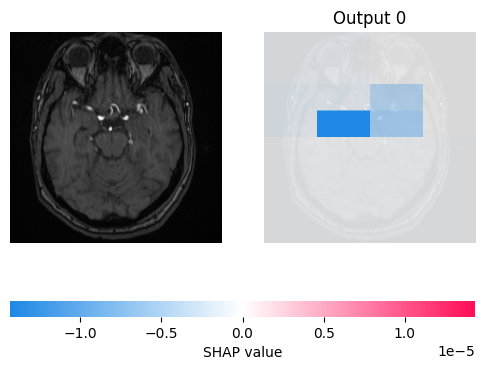


🧠 Custom SHAP Heatmap Overlay with Matplotlib
Failed to create custom SHAP heatmap overlay: [Errno 2] No such file or directory: 'https://prod-images-static.radiopaedia.org/images/61513769/9131de5120872bcc1ad19d8198c759904a4b78efa405550c86ec0f19d3dda590_big_gallery.jpeg'


In [23]:
result, shap_values = fast_shap_analysis(model, image_url)
print(result)

import shap
import matplotlib.pyplot as plt
import numpy as np
import torch

# --- SHAP Built-in Image Plot ---
try:
    print("\n📷 SHAP Image Plot")
    shap.image_plot(shap_values)
except Exception as e:
    print(f"Failed to create SHAP image plot: {e}")

# # --- SHAP Waterfall Plot ---
# try:
#     print("\n🌊 SHAP Waterfall Plot (limited value for image models)")
#     shap.plots.waterfall(shap_values[0])
# except Exception as e:
#     print(f"Failed to create waterfall plot: {e}")

# # --- SHAP Bar Plot ---
# try:
#     print("\n📊 SHAP Bar Plot")
#     shap.plots.bar(shap_values)
# except Exception as e:
#     print(f"Failed to create bar plot: {e}")

# --- ✅ Custom Matplotlib SHAP Heatmap Overlay ---
try:
    print("\n🧠 Custom SHAP Heatmap Overlay with Matplotlib")

    def convert_to_hwc(img_tensor):
        img_np = img_tensor.cpu().detach().numpy()
        if img_np.shape[0] == 3:
            img_np = np.transpose(img_np, (1, 2, 0))  # CHW → HWC
        return img_np

    # Use original image tensor from fast_shap_analysis if accessible
    # If not, you'll need to add it to the return of fast_shap_analysis
    if isinstance(image_url, torch.Tensor):
        image_tensor = image_url
    else:
        # If image_url is a string, load and preprocess manually
        from PIL import Image
        import torchvision.transforms as transforms

        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor()
        ])

        image = Image.open(image_url).convert('RGB')
        image_tensor = transform(image).unsqueeze(0)

    img = convert_to_hwc(image_tensor[0])                  # Original image [H, W, C]
    shap_val = np.transpose(shap_values.values[0], (1, 2, 0))  # SHAP [C, H, W] → [H, W, C]

    shap_overlay = np.abs(shap_val).mean(axis=2)           # RGB → grayscale heatmap
    shap_overlay /= shap_overlay.max() + 1e-8              # Normalize to [0,1]

    plt.figure(figsize=(8, 8))
    plt.imshow(img)                                        # Background image
    plt.imshow(shap_overlay, cmap='hot', alpha=0.5)        # SHAP overlay
    plt.title('SHAP Heatmap Overlay')
    plt.axis('off')
    plt.show()

except Exception as e:
    print(f"Failed to create custom SHAP heatmap overlay: {e}")

Analysis started at 2025-05-20 09:33:49 UTC
Analysis requested by: krooldonutz
Analyzing the image with SHAP...


  0%|          | 0/68 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:49, 49.81s/it]               



📋 Medical Image Analysis Report

🔍 Primary Findings:
• The model did not detect an aneurysm in this image
• Confidence: 77.6%
• Confidence level: moderate

🎯 Key Areas of Interest:
• Most significant region: upper left
• Focus pattern: distributed across multiple areas

💡 Detailed Regional Analysis:
• Upper Left: 53.7% (High attention)
• Upper Right: 28.5% (Medium attention)
• Lower Left: 8.9% (Low attention)
• Lower Right: 8.9% (Low attention)

📖 SHAP Explanation:
• The model's prediction was most strongly influenced by upper left.
• 800 highly influential pixel regions (top 1%) were identified.
• These regions had the greatest positive impact on predicting class 0.
• Bright/red areas on the heatmap indicate strong positive influence toward prediction.
• Blue/dark areas suggest less or negative influence.
• This helps localize where the model 'looked' to make its decision.

⚙️ Technical Metrics:
• Analysis time: 53.1 seconds
• Model stability: -0.78
• Overall importance score: 0.0000

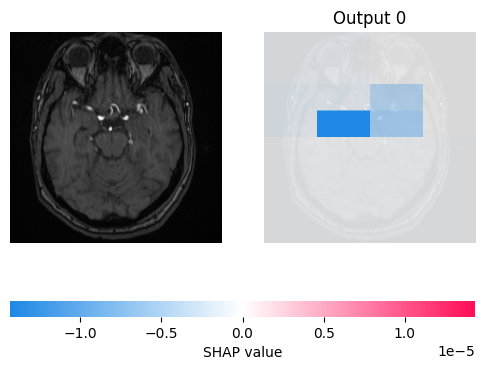


🧠 Custom SHAP Heatmap Overlay with Matplotlib


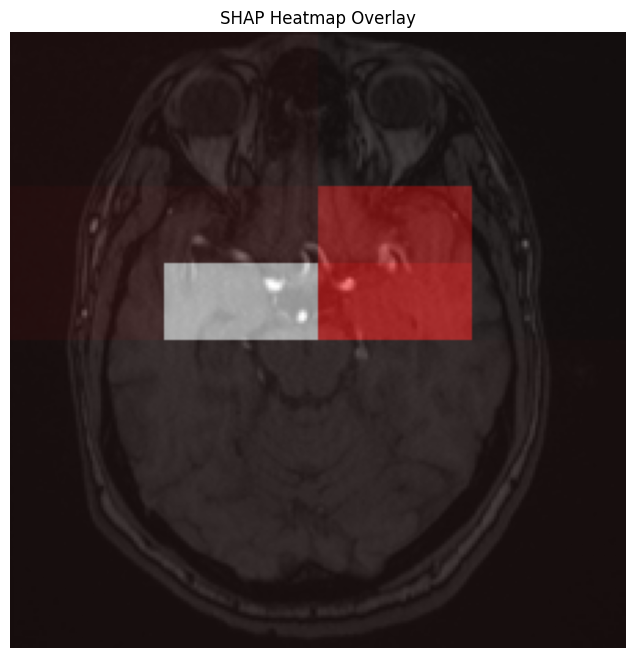

In [24]:
import shap
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import requests
from io import BytesIO

result, shap_values = fast_shap_analysis(model, image_url)
print(result)

# --- SHAP image_plot ---
try:
    print("\n📷 SHAP Image Plot")
    shap.image_plot(shap_values)
except Exception as e:
    print(f"Failed to create SHAP image plot: {e}")

# --- SHAP + Image Overlay with Matplotlib ---
try:
    print("\n🧠 Custom SHAP Heatmap Overlay with Matplotlib")

    # Load and preprocess the image
    if isinstance(image_url, str) and image_url.startswith("http"):
        response = requests.get(image_url)
        image = Image.open(BytesIO(response.content)).convert("RGB")
        image = image.resize((224, 224))
        image_np = np.array(image).astype(np.float32) / 255.0  # (224, 224, 3)
    else:
        raise ValueError("Invalid image URL or type")

    # Extract SHAP values array
    shap_arr = shap_values.values  # could be (1, 224, 224), (224, 224, 3, 1), etc.

    # Squeeze batch or singleton dimensions
    shap_arr = np.squeeze(shap_arr)

    # Convert to 2D heatmap
    if shap_arr.ndim == 3 and shap_arr.shape[-1] == 3:
        # RGB SHAP — average over channels
        heatmap = np.abs(shap_arr).mean(axis=-1)
    elif shap_arr.ndim == 2:
        # Already grayscale
        heatmap = np.abs(shap_arr)
    elif shap_arr.ndim == 3 and shap_arr.shape[0] == 3:
        # Sometimes SHAP comes in (3, 224, 224) — transpose to (224, 224, 3)
        heatmap = np.abs(shap_arr).transpose(1, 2, 0).mean(axis=-1)
    else:
        raise ValueError(f"Unsupported SHAP shape after squeeze: {shap_arr.shape}")

    # Normalize heatmap
    heatmap /= (np.max(heatmap) + 1e-8)

    # Overlay plot
    plt.figure(figsize=(8, 8))
    plt.imshow(image_np)
    plt.imshow(heatmap, cmap='hot', alpha=0.5)
    plt.axis('off')
    plt.title("SHAP Heatmap Overlay")
    plt.show()

except Exception as e:
    print(f"Failed to create custom SHAP heatmap overlay: {e}")


📷 SHAP Image Plot using `shap.plots.image()`


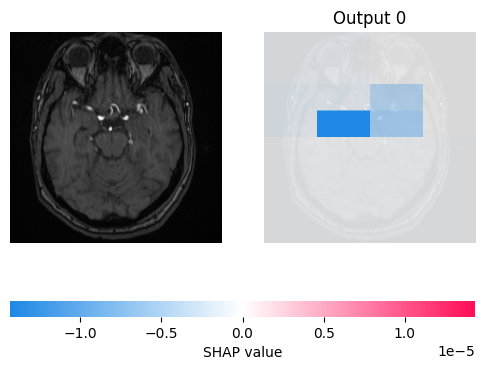

In [25]:
import shap
import matplotlib.pyplot as plt

# Assuming `shap_values` is from a call to GradientExplainer or DeepExplainer
# and `input_image` is the single image you explained (as a tensor or array)

# Plot SHAP image explanation (for single image)
try:
    print("\n📷 SHAP Image Plot using `shap.plots.image()`")
    shap.plots.image(shap_values)
except Exception as e:
    print(f"Failed to create shap.plots.image(): {e}")

In [31]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Assume shap_values.values has shape (1, 224, 224, 3)
# Replace with your actual SHAP values
shap_vals = shap_values

# Assume original_image is the input image with shape (224, 224, 3)
# Replace with your actual image data
original_image = np.random.rand(224, 224, 3)  # Placeholder

# Flatten and average SHAP values across channels
shap_vals_flat = shap_vals[0].reshape(-1, shap_vals.shape[-1])  # (50176, 3)
shap_vals_avg = np.mean(shap_vals_flat, axis=1)  # (50176,)

# Flatten and average image across channels
image_flat = original_image.reshape(-1, original_image.shape[-1])  # (50176, 3)
image_avg = np.mean(image_flat, axis=1)  # (50176,)

# Prepare data for summary plot (no need for extra reshaping)
# shap.summary_plot expects shap_values as (n_samples, n_features), here (1, 50176)
data_for_summary = shap_vals_avg[np.newaxis, :]  # (1, 50176)
image_for_summary = image_avg[np.newaxis, :]  # (1, 50176)

# Create a random number generator to suppress FutureWarning
rng = np.random.default_rng()

# Plot summary with feature values
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values=data_for_summary,
    features=image_for_summary,
    feature_names=[f"pixel_{i}" for i in range(data_for_summary.shape[1])],
    show=True,
    rng=rng  # Pass explicit RNG
)

AttributeError: 'Explanation' object has no attribute 'reshape'

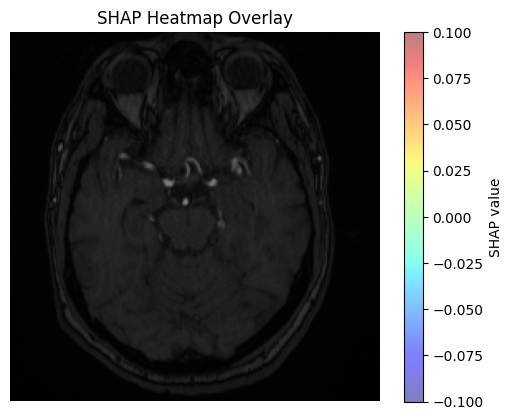

In [27]:
import matplotlib.pyplot as plt

# Convert SHAP values and image to numpy
shap_img = shap_values.values[0].mean(-1)  # mean over channels
original_img = shap_values.data[0]  # shape: (H, W, C)

plt.imshow(original_img / original_img.max())  # normalize if needed
plt.imshow(shap_img, cmap='jet', alpha=0.5)  # overlay heatmap
plt.title("SHAP Heatmap Overlay")
plt.axis('off')
plt.colorbar(label="SHAP value")
plt.show()

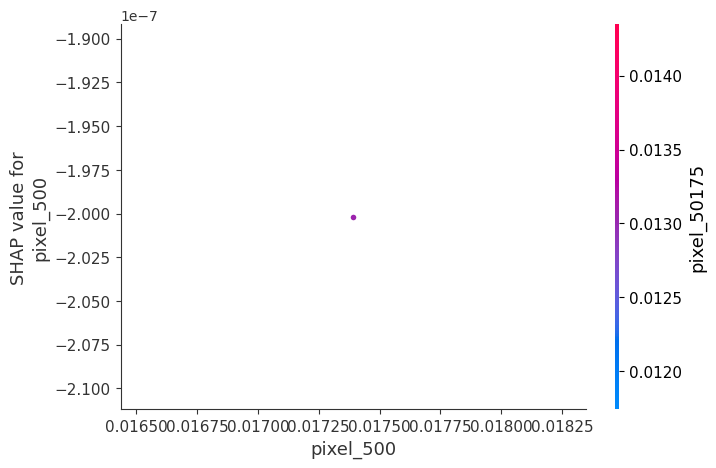

In [28]:
import shap
import numpy as np

# Example with single image SHAP output
# shap_values.values[0] should be shape (H, W, C)
# Let's assume grayscale (C = 1) or take one channel if RGB

shap_img = shap_values.values[0]  # shape: (H, W, C)
input_img = shap_values.data[0]   # shape: (H, W, C)

# Pick one channel (e.g., 0)
shap_flat = shap_img[:, :, 0].flatten()  # shape: (H*W,)
input_flat = input_img[:, :, 0].flatten().reshape(1, -1)  # shape: (1, H*W)

# Now we have many features (pixels) — good for dependence plot
feature_names = [f"pixel_{i}" for i in range(input_flat.shape[1])]

# Choose an index within range
pixel_index = 500  # must be < input_flat.shape[1]

# Plot
shap.dependence_plot(
    ind=pixel_index,
    shap_values=np.expand_dims(shap_flat, axis=0),  # shape (1, num_features)
    features=input_flat,
    feature_names=feature_names
)

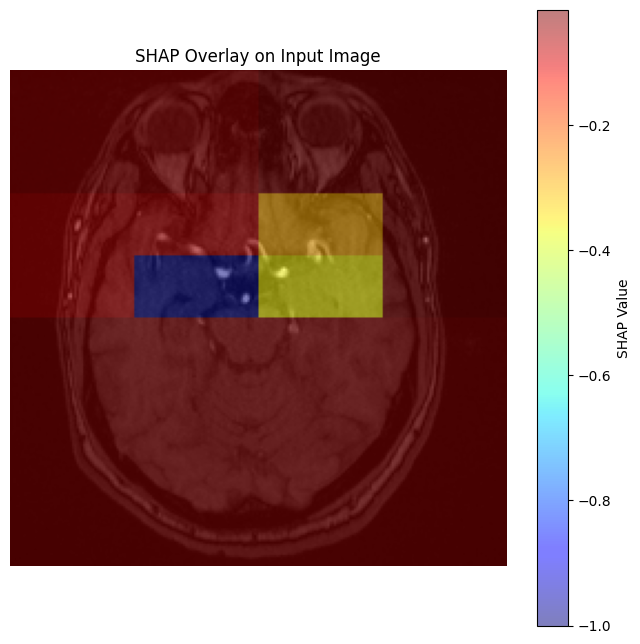

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Extract and squeeze input and SHAP image arrays
input_img = shap_values.data[0]         # Shape: (224, 224, 3)
shap_img = shap_values.values[0]        # Shape: (224, 224, 3, 1)

# Remove extra dimension from SHAP values
shap_img = np.squeeze(shap_img)         # Now shape: (224, 224, 3)

# Convert to grayscale if needed (optional)
input_gray = input_img[:, :, 0] if input_img.ndim == 3 else input_img
shap_gray = shap_img[:, :, 0] if shap_img.ndim == 3 else shap_img

# Normalize SHAP values for better visualization
shap_gray = shap_gray / np.max(np.abs(shap_gray))

# Step 2: Overlay SHAP heatmap on the input image
plt.figure(figsize=(8, 8))
plt.imshow(input_gray, cmap='gray')
plt.imshow(shap_gray, cmap='jet', alpha=0.5)  # overlay SHAP heatmap
plt.colorbar(label='SHAP Value')
plt.title('SHAP Overlay on Input Image')
plt.axis('off')
plt.show()

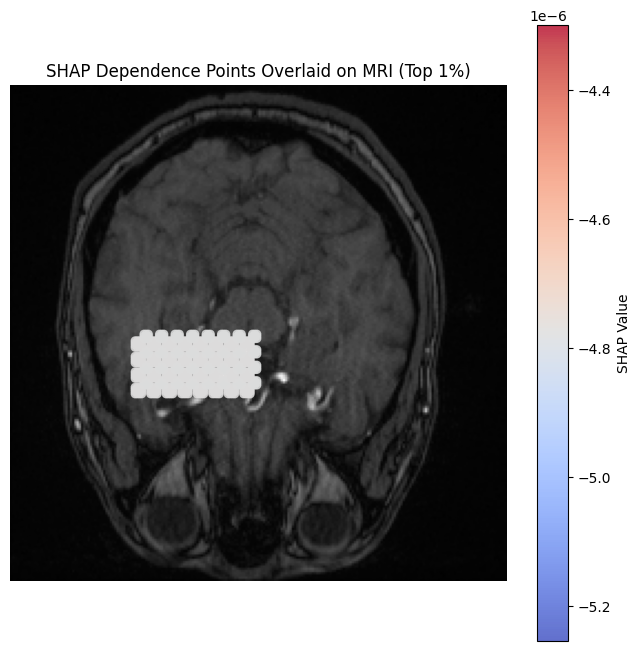

In [44]:
import matplotlib.pyplot as plt
import numpy as np

# Get SHAP values and original image
shap_map_raw = shap_values.values[0]    # shape: (H, W, C, 1) or (H, W, C)
input_img_raw = shap_values.data[0]     # shape: (H, W, C)

# Reduce shap_map to 2D (H, W)
# First, squeeze the last dimension if it's 1
if shap_map_raw.shape[-1] == 1 and shap_map_raw.ndim > 2:
    shap_map_2d = np.squeeze(shap_map_raw, axis=-1) # shape: (H, W, C)
else:
    shap_map_2d = shap_map_raw

# Now, if it's still 3D (H, W, C), take the mean across channels
if shap_map_2d.ndim == 3:
    shap_map = np.mean(shap_map_2d, axis=-1) # shape: (H, W)
elif shap_map_2d.ndim == 2:
     shap_map = shap_map_2d # already 2D
else:
    raise ValueError(f"Unexpected SHAP map shape: {shap_map_2d.shape}")


# Reduce input_img to 2D (H, W) if it's 3D (H, W, C)
if input_img_raw.ndim == 3:
    input_img = np.mean(input_img_raw, axis=-1) # shape: (H, W)
elif input_img_raw.ndim == 2:
    input_img = input_img_raw # already 2D
else:
    raise ValueError(f"Unexpected input image shape: {input_img_raw.shape}")


# Now both should be 2D: (H, W)
H, W = shap_map.shape

x_coords, y_coords = np.meshgrid(np.arange(W), np.arange(H))
x_coords = x_coords.flatten()
y_coords = y_coords.flatten()

pixel_values = input_img.flatten()
shap_values_flat = shap_map.flatten()

# Threshold for significant SHAP values
# Use absolute values for percentile calculation
threshold = np.percentile(np.abs(shap_values_flat), 99)  # Top 1%
mask = np.abs(shap_values_flat) >= threshold

# Filter only important pixels
x_imp = x_coords[mask]
y_imp = y_coords[mask]
shap_imp = shap_values_flat[mask]
intensity_imp = pixel_values[mask]

plt.figure(figsize=(8, 8))
# Use a grayscale colormap for the background image
plt.imshow(input_img, cmap='gray')
# Use a diverging colormap for SHAP values, centered at 0
scatter = plt.scatter(x_imp, y_imp, c=shap_imp, cmap='coolwarm', s=30, alpha=0.8)
plt.colorbar(scatter, label='SHAP Value')
plt.title("SHAP Dependence Points Overlaid on MRI (Top 1%)")
plt.axis('off')
plt.gca().invert_yaxis()  # match image coordinate system
plt.show()

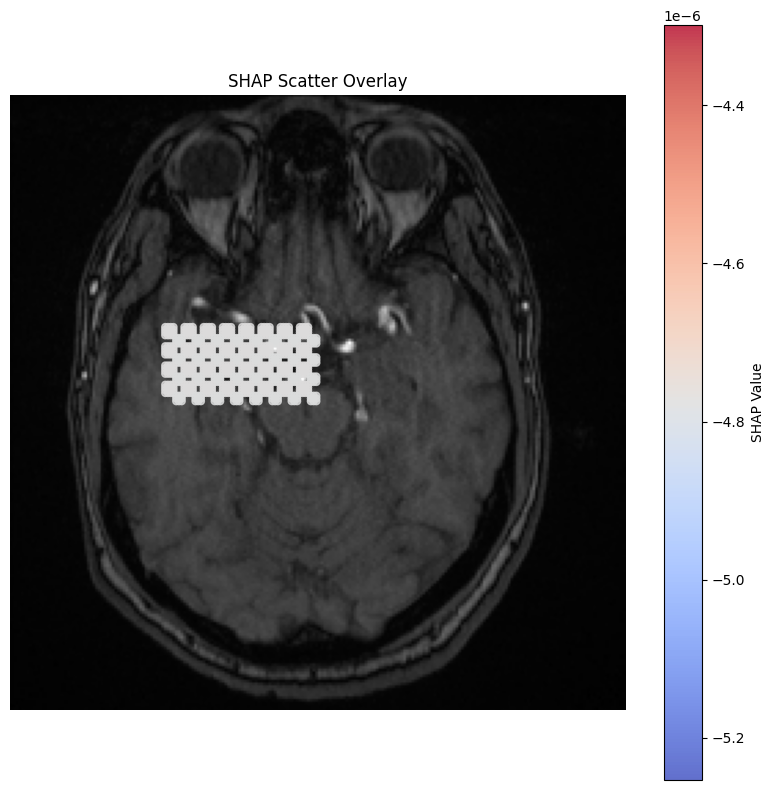

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# Get the input image and SHAP values for class 0
input_img = shap_values.data[0]         # Shape: (H, W, C)
shap_map = shap_values.values[0]        # Shape: (224, 224, 3, 1)

# Convert both to numpy arrays
input_img = np.array(input_img)
shap_map = np.array(shap_map)

# Handle SHAP map shape
if shap_map.ndim == 4:
    shap_map = np.squeeze(shap_map, axis=-1)  # Remove last dimension, shape: (224, 224, 3)
    shap_map_gray = np.mean(shap_map, axis=-1)  # Mean over color channels, shape: (224, 224)
elif shap_map.ndim == 3:
    shap_map_gray = np.mean(shap_map, axis=-1)  # Shape: (H, W)
elif shap_map.ndim == 2:
    shap_map_gray = shap_map
else:
    raise ValueError(f"Unexpected shap_map shape: {shap_map.shape}")

# Force input image to RGB format
if input_img.ndim == 2:
    input_img = np.stack([input_img]*3, axis=-1)
elif input_img.shape[-1] == 1:
    input_img = np.repeat(input_img, 3, axis=-1)

# Scale image to 0-255 if normalized
if input_img.max() <= 1.0:
    input_img = input_img * 255

# Confirm shapes
assert shap_map_gray.ndim == 2, f"shap_map_gray must be 2D, got shape: {shap_map_gray.shape}"
assert input_img.ndim == 3 and input_img.shape[2] == 3, f"Expected RGB input image, got shape: {input_img.shape}"

# Image dimensions
H, W = shap_map_gray.shape

# Flatten coordinates and SHAP values
x_coords, y_coords = np.meshgrid(np.arange(W), np.arange(H))
x_flat = x_coords.flatten()
y_flat = y_coords.flatten()
shap_flat = shap_map_gray.flatten()

# Keep pixels with high SHAP values (top 3%)
threshold = np.percentile(np.abs(shap_flat), 97)
mask = np.abs(shap_flat) > threshold

# Plot over image
plt.figure(figsize=(8, 8))
plt.imshow(input_img.astype(np.uint8))
plt.scatter(
    x_flat[mask],
    y_flat[mask],
    c=shap_flat[mask],
    cmap='coolwarm',
    s=25,
    alpha=0.8
)
plt.colorbar(label='SHAP Value')
plt.title("SHAP Scatter Overlay")
plt.axis('off')
plt.tight_layout()
plt.show()

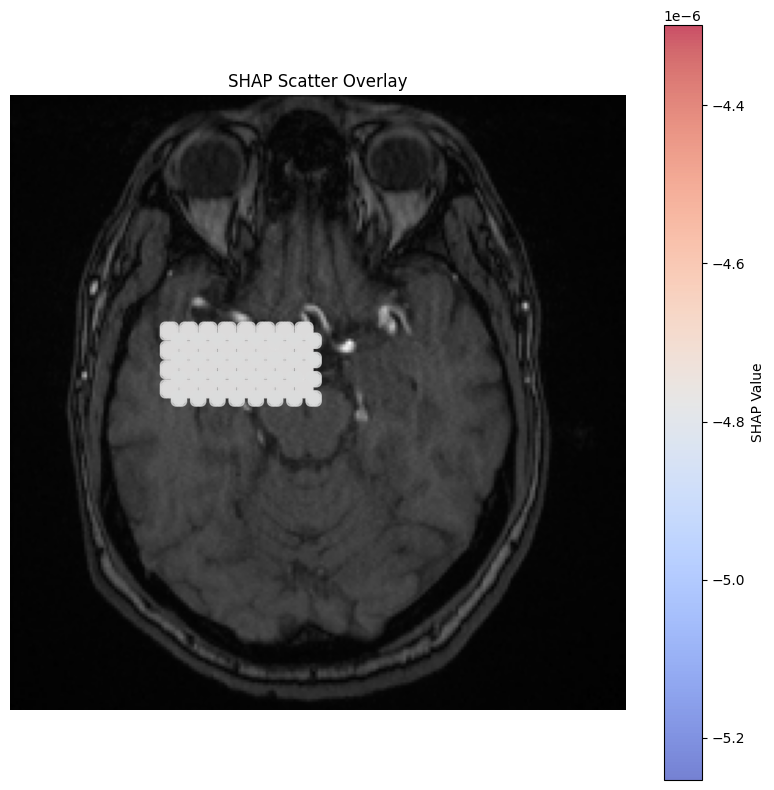

In [56]:
import numpy as np
import matplotlib.pyplot as plt

# Get the input image and SHAP values for class 0
input_img = shap_values.data[0]         # Shape: (H, W, C)
shap_map = shap_values.values[0]        # Shape: (224, 224, 3, 1)

# Convert both to numpy arrays
input_img = np.array(input_img)
shap_map = np.array(shap_map)

# Handle SHAP map shape
if shap_map.ndim == 4:
    shap_map = np.squeeze(shap_map, axis=-1)  # Remove last dimension, shape: (224, 224, 3)
    shap_map_gray = np.mean(shap_map, axis=-1)  # Mean over color channels, shape: (224, 224)
elif shap_map.ndim == 3:
    shap_map_gray = np.mean(shap_map, axis=-1)  # Shape: (H, W)
elif shap_map.ndim == 2:
    shap_map_gray = shap_map
else:
    raise ValueError(f"Unexpected shap_map shape: {shap_map.shape}")

# Force input image to RGB format
if input_img.ndim == 2:
    input_img = np.stack([input_img]*3, axis=-1)
elif input_img.shape[-1] == 1:
    input_img = np.repeat(input_img, 3, axis=-1)

# Scale image to 0-255 if normalized
if input_img.max() <= 1.0:
    input_img = input_img * 255

# Confirm shapes
assert shap_map_gray.ndim == 2, f"shap_map_gray must be 2D, got shape: {shap_map_gray.shape}"
assert input_img.ndim == 3 and input_img.shape[2] == 3, f"Expected RGB input image, got shape: {input_img.shape}"

# Image dimensions
H, W = shap_map_gray.shape

# Flatten coordinates and SHAP values
x_coords, y_coords = np.meshgrid(np.arange(W), np.arange(H))
x_flat = x_coords.flatten()
y_flat = y_coords.flatten()
shap_flat = shap_map_gray.flatten()

# Keep pixels with high SHAP values (top 3%)
threshold = np.percentile(np.abs(shap_flat), 97)
mask = np.abs(shap_flat) > threshold

# Plot over image
plt.figure(figsize=(8, 8))
plt.imshow(input_img.astype(np.uint8))
plt.scatter(
    x_flat[mask],
    y_flat[mask],
    c=shap_flat[mask],
    cmap='coolwarm',  # Red-to-blue gradient
    s=50,  # Larger points for visibility
    alpha=0.7  # Slightly reduced transparency
)
plt.colorbar(label='SHAP Value')
plt.title("SHAP Scatter Overlay")
plt.axis('off')
plt.tight_layout()
plt.show()